# Experimentation and discussion on CLOP technique for preventing dimensional collapse on contrastive learning ####

## Introduction
In this notebook, we explore the phenomenon of **neural collapse** in contrastive learning and understand the motivation behind **CLOP (Contrastive Learning with Orthonormal Prototypes)**, as described in Paper A in the repositry ./docs.

Neural collapse is observed during the training of deep networks, especially in contrastive learning, and can manifest in two ways:

1. **Complete collapse:** all embeddings merge into a single point or line (co-linear), often caused by excessively large learning rates.  
2. **Dimensional collapse:** embeddings spread out but occupy a **lower-dimensional subspace**, reducing spatial utilization and making classes less distinguishable.

This notebook focuses on **dimensional collapse**, which is the primary issue addressed by CLOP.

**Objectives:**

1. Generate synthetic class embeddings and simulate simple scenarios.  
2. Visualize embeddings using dimensionality reduction (e.g., PCA) and study their distribution.  
3. Quantify collapse using metrics like **pairwise cosine similarity** and **covariance spectrum**.  
4. Lay the groundwork for understanding how CLOP aligns embeddings with **orthonormal prototypes** to prevent collapse.

This notebook is designed for hands-on exploration and understanding, with a focus on **mathematical and visual intuition** rather than deep learning implementation details.

A big thank you to **Professor Clovis Gliez**, my supervisor for this project.  

In [1]:
import numpy as np
from numpy.linalg import svd, norm
import matplotlib.pyplot as plt
import seaborn as sns  # for plots
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
# PyTorch
import torch
import torch.nn.functional as F

# settings
torch.set_default_dtype(torch.float32)
torch.manual_seed(42)
np.random.seed(42)
sns.set(style="whitegrid")

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# 0.3 Initialize embeddings
k = 30  # number of classes
m = 64  # embedding dimension
X = np.random.randn(m, k)
np.random.seed(42)
X /= norm(X, axis=0, keepdims=True)  # normalize each column

# Optional: create labeled subset S for CLOP later
labels = np.arange(k)

## Singular Value Decomposition (SVD): Proof and Significance

In this section, we explain **Singular Value Decomposition (SVD)**, the significance of singular values, and how to construct the decomposition from first principles.  

### 1. SVD Statement

Let $X \in \mathbb{R}^{m \times n}$ be a real matrix of rank $r \le \min(m, n)$. Then there exist orthonormal matrices

$$
U \in \mathbb{R}^{m \times m}, \quad V \in \mathbb{R}^{n \times n}
$$

and a diagonal matrix $\Sigma \in \mathbb{R}^{m \times n}$ such that

$$
X = U \Sigma V^T
$$

where $\Sigma = \mathrm{diag}(\sigma_1, \dots, \sigma_r, 0, \dots, 0)$ with $\sigma_i > 0$ called the **singular values** of $X$.  


### 2. Significance of Singular Values

1. Each $\sigma_i$ measures the "strength" or "importance" of the corresponding direction $v_i$ in the input space.  
2. Directions $v_i$ with larger $\sigma_i$ contribute more to the image of $X$.  
3. The rank of $X$ is the number of non-zero singular values:  

$$
\text{rank}(X) = r = |\{i : \sigma_i \neq 0\}|
$$

4. The vectors $u_i = \frac{1}{\sigma_i} X v_i$ form an orthonormal basis of $\mathrm{Im}(X)$, while the remaining columns of $U$ span $\ker(X^T)$.  


### 3. Construction of SVD


- Compute $X^T X \in \mathbb{R}^{n \times n}$. It is symmetric and positive semi-definite.  
- Let $(v_i, \lambda_i)$ be eigenpairs of $X^T X$:  

$$
X^T X v_i = \lambda_i v_i
$$

- Define singular values: $\sigma_i = \sqrt{\lambda_i} > 0$ for non-zero $\lambda_i$.  

$$
u_i = \frac{1}{\sigma_i} X v_i \quad \text{for } i = 1, \dots, r
$$

- Then $\|u_i\| = 1$, because

$$
\|u_i\|^2 = \frac{1}{\sigma_i^2} \|X v_i\|^2 = \frac{1}{\sigma_i^2} v_i^T X^T X v_i = \frac{\lambda_i}{\sigma_i^2} = 1
$$

- These $u_i$ span $\mathrm{Im}(X)$ forming a basis for it.
In fact:
- $u_i \in \mathrm{Im}(X)$
- $dim(\mathrm{Im}(X))$ = $dim(u_1,\dots,u_{r})$ (because the rest of eigenvectors span the Ker).
- $u_i$ 's are linearly independant, as $(v_1,\dots,v_{r})$ form an orthonormal basis.


- **Left basis $U$**: Extend $\{u_1, \dots, u_r\}$ to an orthonormal basis of $\mathbb{R}^m$ by adding a basis of $\ker(X^T)$.  
  - **Existence:** Gram–Schmidt guarantees that any subspace of finite dimension has an orthonormal basis, including $\ker(X^T)$.  
  - Let these extra vectors be $u_{r+1}, \dots, u_m$. As these vectors form an orthonormal basis of $\ker(X^T)$, $\{u_1, \dots, u_r\}$ form an orthonormal family, and **the two families are orthogonal to each other because $\mathrm{Im}(X)$ is orthogonal to $\ker(X^T)$**.  


- **Right basis $V$**: Extend $\{v_1, \dots, v_r\}$ to an orthonormal basis of $\mathbb{R}^n$ using a basis of $\ker(X)$.  


$$
\Sigma = 
\begin{bmatrix}
\sigma_1 & & 0 & & 0 \\
& \ddots & & & \vdots \\
0 & & \sigma_r & & 0 \\
0 & \dots & 0 & 0 & 0 \\
\end{bmatrix} \in \mathbb{R}^{m \times n}
$$

- The first $r$ diagonal entries are positive singular values.  
- Remaining entries are zero.  

- For $i \le r$:  

$$
X v_i = X V e_i = \sigma_i u_i \quad \Rightarrow \quad X V = U \Sigma
$$

- Multiplying both sides by $V^T$:  

$$
X = U \Sigma V^T
$$

- The decomposition is **exact**, and $U, V$ are orthonormal.  


### 4. Summary of Key Points

- Singular values $\sigma_i$ quantify **directional contributions**.  
- Left singular vectors $u_i$ are directions in output space; right singular vectors $v_i$ are directions in input space.  
- Non-zero singular values correspond to the **image of $X$**; zeros correspond to the **kernel of $X$**.  
- Orthonormality ensures that $U^T U = I_m$ and $V^T V = I_n$.  
- This construction is **always possible** for any real matrix $X$.  



### 5. Connection to Directional Contributions in Contrastive Learning

In the context of contrastive learning:

- Each **singular value $\sigma_i$** measures how much the data stretches along the corresponding right singular vector $v_i$.  
- Directions with **large singular values** capture the most variance or information in the data — these are the "meaningful" directions.  
- Directions with **small or zero singular values** contribute very little or nothing; they correspond to collapsed or redundant dimensions.  
- By analyzing the **spectrum of singular values**, we can identify which directions are dominant, and which ones may be collapsing — a key insight for understanding phenomena like **neural collapse** in feature representations.  

Thus, **singular values provide a quantitative way to measure the contribution of each direction**, guiding both analysis and potential regularization strategies in contrastive and self-supervised learning.


### 6. Exploring the Singular Value Spectrum of Class Embeddings

To better understand how the class embeddings occupy the representation space, we compute the **singular values** of the embedding matrix \(X\).  

These singular values quantify the contribution of each orthogonal direction in the embedding space. Large singular values correspond to directions with high variance (important features), while small values indicate collapsed or underutilized directions. By visualizing the spectrum, we can gain intuition on **dimensional collapse** and assess which directions are effectively used by the model.

Here, instead of a chart for better visualization.


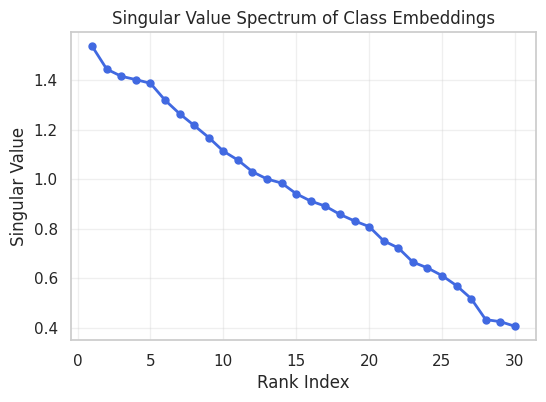

In [ ]:

U, S_vals, Vh = svd(X)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(S_vals)+1), S_vals, 'o-', color='royalblue', markersize=5, linewidth=2)
plt.title("Singular Value Spectrum of Class Embeddings")
plt.xlabel("Rank Index")
plt.ylabel("Singular Value")
plt.grid(alpha=0.3)
plt.show()


**Comment:** 

Even with random vectors (no cosine similarity or contrastive loss applied), the singular values naturally decay. This happens because in finite dimensions, some directions accidentally capture more variance than others, and the effective rank of the data is limited. Contrastive learning later amplifies this effect, concentrating variance along a few dominant directions, which is key to the phenomenon of neural collapse.


## Analysis of Contrastive Loss and Collapse

## 1. Introduction to the Collapse Phenomenon
The primary cause of **dimensional collapse** lies in the repulsive forces between different classes. When there is an "overfitting" of these forces, the classes try to move away so violently and so quickly that they end up colliding (collapse).

---

## 2. Definition of Contrastive Loss (InfoNCE)
The total loss for a set of indices $I$ is defined by:
$$\mathcal{L}_{infoNCE} = - \sum_{i \in I} \log P_i = \sum_{i \in I} \mathcal{L}_i$$

Where for each sample $i$, the probability $P_i$ is:
$$P_i = \frac{\exp(z_i \cdot z_{j(i)} / \tau)}{\sum_{b \in I \setminus \{i\}} \exp(z_i \cdot z_b / \tau)}$$

**Parameters :**
* $j(i)$ : the index of the **positive pair vector**.
* $\tau$ : temperature parameter.
* $z_i$ : representation vectors (generally normalized $\|z\| = 1$).

This loss is strongly linked to the **cosin similarity loss** that we will be using in more simplified scenarios afterwards (we will demonstrate there closeness once we're there)


## 3. Complete Collapse
To understand learning, we compute the derivative of the loss with respect to $z_i$ :
$$\frac{\partial \mathcal{L}_i}{\partial z_i} = - \frac{1}{P_i} \frac{\partial P_i}{\partial z_i}$$
In fact this is a step stone to studying the **gradient** as we encounter a **complete collapse**.

### Derivation of $P_i$
Using the quotient rule $\left( \frac{u}{v} \right)' = \frac{u'v - uv'}{v^2}$ :

$$\begin{split} 
\frac{\partial P_i}{\partial z_i} &= \frac{\frac{1}{\tau} z_{j(i)} \exp(\frac{z_i z_{j(i)}}{\tau}) \sum_{b \neq i} \exp - \exp(\frac{z_i z_{j(i)}}{\tau}) \sum_{b \neq i} \frac{1}{\tau} z_b \exp(\frac{z_i z_b}{\tau})}{\left( \sum_{b \neq i} \exp \right)^2} \\
&= \frac{1}{\tau} \left[ z_{j(i)} P_i - P_i \left( \sum_{b \neq i} z_b 
\frac{\exp(\frac{z_i z_b}{\tau})}{\sum_{b \neq i} \exp} \right) \right] \\
&= \frac{1}{\tau} \left[ z_{j(i)} P_i - P_i \left( \sum_{b \neq i, j(i)} z_b 
\frac{\exp(\frac{z_i z_b}{\tau})}{\sum_{b \neq i} \exp} + z_{j(i)} P_i\right)   \right] \\
\\
&= \frac{1}{\tau} P_i \left[ z_{j(i)} - \sum_{b \neq i, j(i)} P_b z_b - P_iz_{j(i)} \right]\\
&= \frac{1}{\tau} P_i \left[ z_{j(i)}(1 - P_i) - \sum_{b \neq i, j(i)} P_b z_b \right]
\end{split}$$

### Final gradient of the loss
By reinjecting into $\frac{\partial \mathcal{L}_i}{\partial z_i}$ :
$$\frac{\partial \mathcal{L}_i}{\partial z_i} = -\frac{1}{\tau} \left( (1 - P_i) z_{j(i)} - \sum_{a \neq i, j(i)} P_a z_a \right)$$

---

## 4. Collapse Scenario
Suppose all representations collapse toward a single vector $z^*$ :
$z_i = z_{j(i)} = z_a = z^*$.

In this state :
1. Probabilities become uniform : $P^* = \frac{1}{\text{card}(I) - 1}$.
2. The sum of the other samples becomes : $\sum_{a \neq i, j(i)} P_a z_a = (\text{card}(I) - 2) P^* z^*$.

The gradient then becomes :
$$\begin{split}
\frac{\partial \mathcal{L}_i}{\partial z_i} &= -\frac{1}{\tau} \left[ (1 - P^*) z^* - (\text{card}(I) - 2) P^* z^* \right] \\
&= -\frac{1}{\tau} z^* \left[ 1 - P^* - \text{card}(I) P^* + 2P^* \right] \\
&= -\frac{1}{\tau} z^* \left[ 1 + P^* - \text{card}(I) P^* \right]
\end{split}$$

By replacing $P^*$ with its value :
$$1 - (\text{card}(I) - 1) P^* = 1 - 1 = 0$$

**Conclusion :**
$$\frac{\partial \mathcal{L}_i}{\partial z_i} = 0$$
The gradient vanishes, which means the model can no longer escape this collapse state on its own.



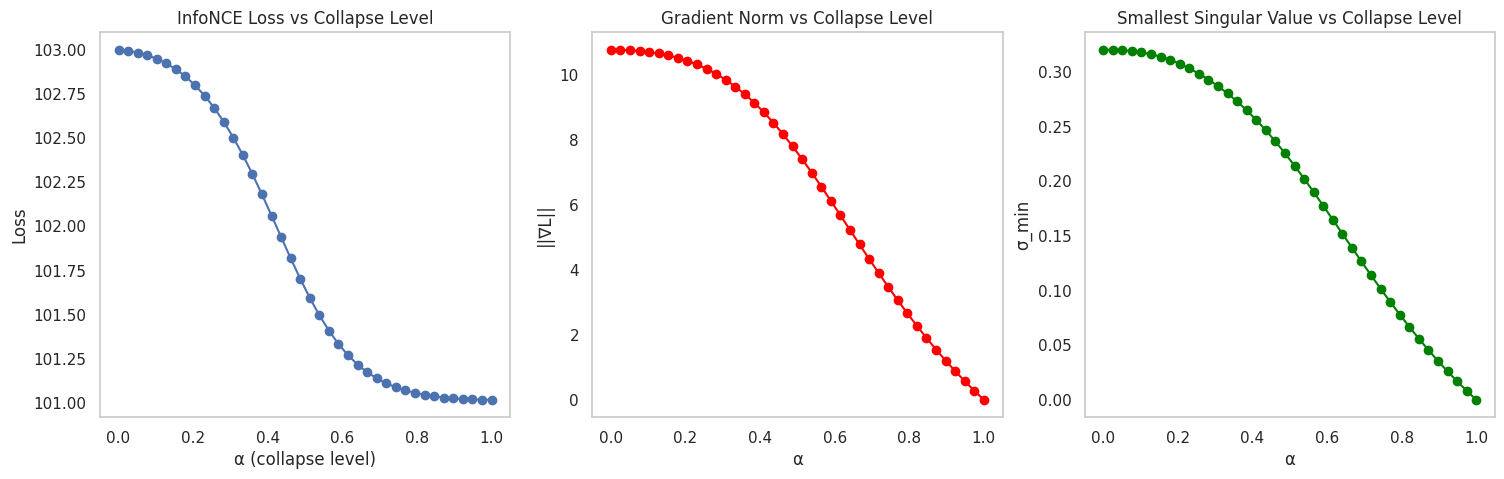

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#############################
# Parameters
#############################

m = 50
N = 30
tau = 0.5
alphas = np.linspace(0, 1, 40)



def normalize_columns(X):
    return X / np.linalg.norm(X, axis=0, keepdims=True)

def infoNCE_loss(Z, tau):
    N = Z.shape[1]
    total_loss = 0

    for i in range(N):
        zi = Z[:, i]
        sims = np.dot(zi, Z) / tau
        sims[i] = -np.inf

        exp_sims = np.exp(sims)
        denom = np.sum(exp_sims)

        j = (i + 1) % N
        Pi = exp_sims[j] / denom
        total_loss += -np.log(Pi)

    return total_loss

def infoNCE_gradient(Z, tau):
    N = Z.shape[1]
    grads = np.zeros_like(Z)

    for i in range(N):
        zi = Z[:, i]
        j = (i + 1) % N

        sims = np.dot(zi, Z) / tau
        sims[i] = -np.inf

        exp_sims = np.exp(sims)
        denom = np.sum(exp_sims)
        P = exp_sims / denom

        Pi = P[j]

        neg_sum = np.zeros(m)
        for a in range(N):
            if a != i and a != j:
                neg_sum += P[a] * Z[:, a]

        grads[:, i] = -(1/tau) * ((1 - Pi) * Z[:, j] - neg_sum)

    return grads


# Generate base states


Z_random = normalize_columns(np.random.randn(m, N))

z_star = np.random.randn(m, 1)
z_star /= np.linalg.norm(z_star)
Z_collapse = np.repeat(z_star, N, axis=1)


# Experiment

losses = []
grad_norms = []
min_singular = []

for alpha in alphas:

    Z = (1 - alpha) * Z_random + alpha * Z_collapse
    Z = normalize_columns(Z)

    losses.append(infoNCE_loss(Z, tau))
    grad_norms.append(np.linalg.norm(infoNCE_gradient(Z, tau)))

    _, S, _ = np.linalg.svd(Z, full_matrices=False)
    min_singular.append(S[-1])


# Plot


fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].plot(alphas, losses, 'o-')
axes[0].set_title("InfoNCE Loss vs Collapse Level")
axes[0].set_xlabel("α (collapse level)")
axes[0].set_ylabel("Loss")
axes[0].grid()

axes[1].plot(alphas, grad_norms, 'o-', color='red')
axes[1].set_title("Gradient Norm vs Collapse Level")
axes[1].set_xlabel("α")
axes[1].set_ylabel("||∇L||")
axes[1].grid()

axes[2].plot(alphas, min_singular, 'o-', color='green')
axes[2].set_title("Smallest Singular Value vs Collapse Level")
axes[2].set_xlabel("α")
axes[2].set_ylabel("σ_min")
axes[2].grid()

plt.show()


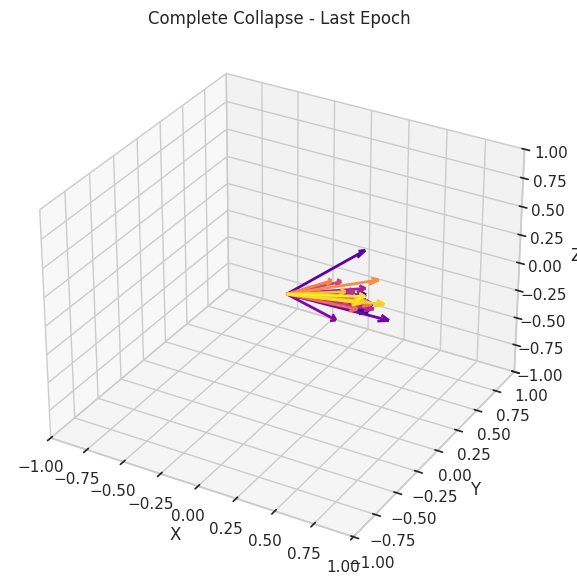

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)  

# Paramètres

m = 3
k = 30
epochs = 15
step = 0.2


# Initial Embeddings

X = np.random.randn(m, k)
X /= np.linalg.norm(X, axis=0, keepdims=True)

# Unique target point for collapse
z_star = np.random.randn(m,1)
z_star /= np.linalg.norm(z_star)
Z_target = np.repeat(z_star, k, axis=1)

# ---------------------
# Simulation du complete collapse
# ---------------------
for epoch in range(epochs):
    X = (1 - step) * X + step * Z_target
    X /= np.linalg.norm(X, axis=0, keepdims=True)

# ---------------------
# 3D Visualization 
# ---------------------
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim([-1,1]); ax.set_ylim([-1,1]); ax.set_zlim([-1,1])
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Complete Collapse - Last Epoch")

for i in range(k):
    ax.quiver(0,0,0, X[0,i], X[1,i], X[2,i], color=plt.cm.plasma(i/k), linewidth=2, arrow_length_ratio=0.1)

plt.show()


## Theorem 1: Upper Bound on Learning Rate for Cosine Minimization

**Theorem 1.** Consider $k$ class embeddings uniformly distributed on the surface of an $m$-dimensional unit ball, where $m \ge k > 2$.  

The upper bound on the learning rate $\mu$ for the gradient descent step, to minimize cosine similarity scores between class embeddings **while preventing the class embedding mean from increasing by a ratio of $(1 + \varepsilon)$**, is given by:

$$
(1 - \eta)² \le (1 + \frac{\eta}{k - 1} - 2\frac{\eta²}{k(k-1)} + \frac{\eta²k}{(k-1)²})(1 + \varepsilon)^2
$$

Setting $\varepsilon = 0$ guarantees a **non-increasing mean**, and provides an upper bound for the learning rate of $2 + O(k^{-1})$.


### Goal of Our Experiment

We want to **verify the validity of Theorem 1 numerically**:

1. Initialize $k$ embeddings uniformly on the $m$-dimensional unit sphere.  
2. Apply the gradient descent update from the theorem:

$$
x_i \leftarrow \left(1 + \frac{\eta}{k-1}\right) x_i - \frac{k \eta}{k-1} \mu, \quad \mu = \frac{1}{k} \sum_{i=1}^k x_i
$$

3. Track **singular values** and **total cosine similarity loss** over epochs.  
4. Observe whether the embeddings **collapse rapidly** (singular values → 0) or remain stable, depending on $\eta$.  

This will allow us to see **how the learning rate affects neural collapse**, and whether the theoretical upper bound accurately predicts the dynamics in practice.


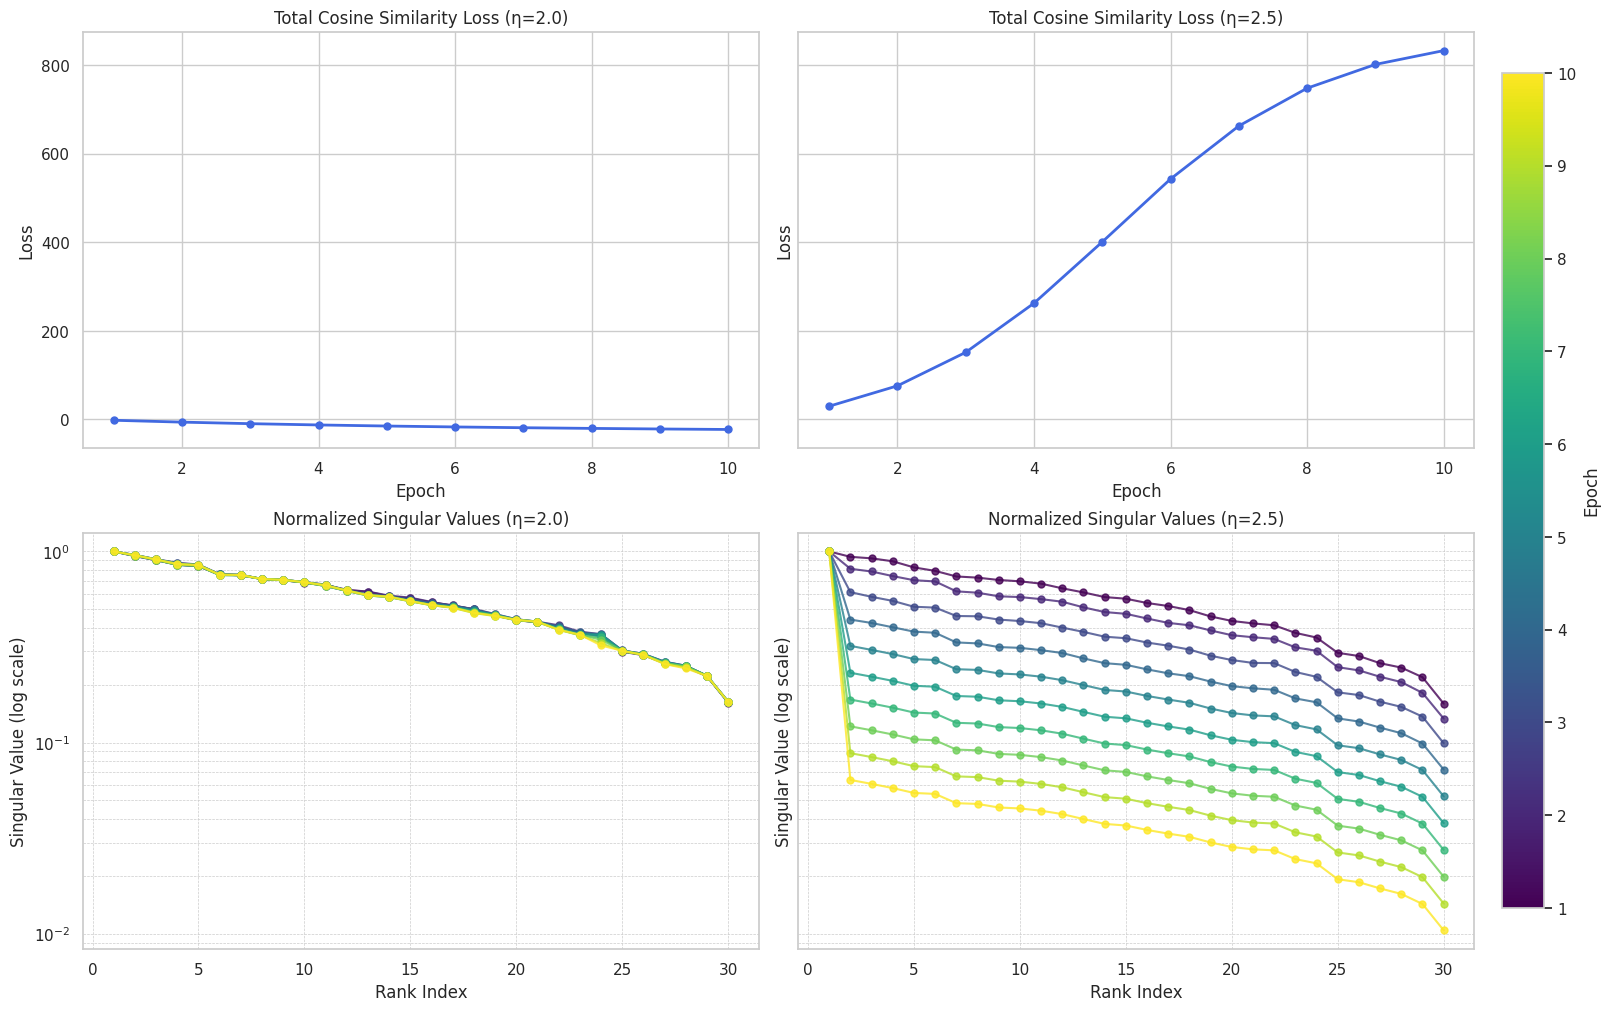

In [ ]:

##################### Parameters #########################
m = 50       # embedding dimension
k = 30       # number of class embeddings
epochs = 10
etas = [2.0, 2.5]  # learning rates to compare


######## Function to sample k points uniformly on m-dimensional unit sphere #########

def sample_unit_sphere(m, k):
    X = np.random.randn(m, k)
    X /= np.linalg.norm(X, axis=0, keepdims=True)
    return X

################" Cosine similarity functions ##################

def pairwise_cosine_similarity(X):
    X_norm = X / np.linalg.norm(X, axis=0, keepdims=True)
    sim_matrix = X_norm.T @ X_norm
    np.fill_diagonal(sim_matrix, 0)
    return sim_matrix

def total_cosine_loss(X):
    return np.sum(pairwise_cosine_similarity(X))

############### Gradient descent simulation (paper dynamics) ################
def simulate_collapse(X_init, eta, epochs):
    X = X_init.copy()
    singular_values_history = []
    losses = []

    for epoch in range(epochs):
        mu = np.mean(X, axis=1, keepdims=True)
        X = (1 + eta/(k-1)) * X - (k*eta/(k-1)) * mu
        X /= np.linalg.norm(X, axis=0, keepdims=True)  # unit normalization

        _, S_vals, _ = np.linalg.svd(X, full_matrices=False)
        singular_values_history.append(S_vals)
        losses.append(total_cosine_loss(X))

    return singular_values_history, losses

X0 = sample_unit_sphere(m, k) # initial embeddings

############# Run simulations for both etas (an eta on the limit given by the theorem and an eta bigger than it) ##########

results = {}
for eta in etas:
    results[eta] = simulate_collapse(X0, eta, epochs)

############### Plotting ################

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey='row', constrained_layout=True)


colors = plt.cm.viridis(np.linspace(0,1,epochs))

for col, eta in enumerate(etas):
    singular_values_history, losses = results[eta]

    # Plot loss
    axes[0, col].plot(range(1, epochs+1), losses, 'o-', color='royalblue',
                      markersize=5, linewidth=2)
    axes[0, col].set_title(f"Total Cosine Similarity Loss (η={eta})")
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].set_ylabel("Loss")
    axes[0, col].grid(True)

    # Plot singular values evolution (log scale, for more visibile effect)
    for epoch_idx, S_vals in enumerate(singular_values_history):
        S_scaled = S_vals / S_vals[0]
        axes[1, col].semilogy(range(1, len(S_scaled)+1), S_scaled,
                              'o-', color=colors[epoch_idx], markersize=5, linewidth=1.5, alpha=0.8)
    axes[1, col].set_title(f"Normalized Singular Values (η={eta})")
    axes[1, col].set_xlabel("Rank Index")
    axes[1, col].set_ylabel("Singular Value (log scale)")
    axes[1, col].grid(True, which="both", ls="--", lw=0.5)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=1, vmax=epochs))
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label("Epoch")


plt.show()


## Empirical Evidence of the Phase Transition

The results provide strong empirical evidence for the phase transition predicted by the theorem.



### 1. Stability of Total Cosine Similarity Loss

**Stable Regime ($\eta = 2.0$)**  
In the top-left plot, the loss remains near zero and shows a slight, controlled decrease. This indicates that the embeddings maintain their spatial distribution without diverging or collapsing.

**Unstable Regime ($\eta = 2.5$)**  
In the top-right plot, the loss increases monotonically and rapidly. This suggests that when $\eta$ exceeds the theoretical bound (approximately $2 + \mathcal{O}(k^{-1})$), the gradient descent step fails to minimize cosine similarity effectively, leading to divergence in the embedding dynamics.



### 2. Evolution of Singular Values (Neural Collapse)

The bottom row of plots tracks the **normalized singular values** of the embedding matrix over 10 epochs (indicated by the color gradient from dark purple to yellow).

**$\eta = 2.0$ (Convergence to Equilateral State)**

- The singular values remain tightly clustered across all epochs.  
- The near overlap between Epoch 1 and Epoch 10 suggests that the system is in a stable equilibrium.  
- This behavior is consistent with convergence to a *Simplex Equiangular Tight Frame (ETF)* configuration, where embeddings are maximally spread.

**$\eta = 2.5$ (Rapid Neural Collapse)**

- A clear downward shift in the singular value spectrum is observed as epochs progress (purple to yellow).  
- By Epoch 10 (yellow curve), the singular values have dropped by nearly an order of magnitude (log scale).  
- This confirms that the class embedding mean increases while individual vectors lose rank, effectively collapsing toward a single point.



### Key Observations

| Metric | $\eta = 2.0$ (Within Bound) | $\eta = 2.5$ (Exceeding Bound) |
|--------|----------------------------|--------------------------------|
| Loss Behavior | Decreasing / Stable | Explosive Growth |
| Rank / Singular Values | Preserved | Rapid Decay (Collapse) |
| Theorem Alignment | Validates collapse | Demonstrates collapse when $\eta > 2$ |



### Conclusion

The numerical results strongly support Theorem 1. The transition from stability to collapse occurs precisely as $\eta$ surpasses the predicted threshold. When $\eta = 2.5$, the gradient step is overly aggressive, causing embeddings to move toward the global mean faster than they can minimize inter-class similarity, resulting in neural collapse.

## Geometric Visualization and Variance Analysis of Dimensional Collapse

After demonstrating the occurrence of **dimensional collapse** through the study of singular values, we now turn to a **geometric visualization** of the embeddings. This step allows us to **observe how the vectors align in space** and how the variance is distributed across different directions.

By applying **Principal Component Analysis (PCA)**, we can:

- Identify the **directions of maximum variance** in the embeddings.
- Quantify the **cumulative variance** captured by the principal components.
- Visualize whether the embeddings are confined to a lower-dimensional subspace (planar or linear structure).

This geometric perspective complements the singular value analysis, providing an **intuitive understanding of how dimensional collapse manifests** in the spatial configuration of the embeddings.

## Principal Component Analysis (PCA) and Explained Variance

Let $ X \in \mathbb{R}^{m \times k} $ be a matrix of embeddings, where each column $ x_i $ is a normalized embedding vector of dimension $ m $.

---

### Centering the Data

To apply PCA, we first center the data around its mean:

$$
\mu = \frac{1}{k} \sum_{i=1}^{k} x_i \in \mathbb{R}^{m}, \quad
\tilde{X} = X - \mu \mathbf{1}^\top
$$

where $ \mathbf{1} \in \mathbb{R}^{k} $ is a vector of ones.

Centering ensures that the first principal component captures the **direction of maximum variance** around the data center.


### Covariance Matrix

Next, we compute the covariance matrix:

$$
\Sigma = \frac{1}{k} \tilde{X} \tilde{X}^\top \in \mathbb{R}^{m \times m}
$$

This matrix describes how different dimensions are correlated.


### Spectral Decomposition

We compute the eigenvalues and eigenvectors of $\Sigma$:

$$
\Sigma v_i = \lambda_i v_i, \quad i=1,\dots,m
$$

where:

- $ v_i $ are the eigenvectors (principal directions, orthonormal)  
- $ \lambda_i \ge 0 $ are the eigenvalues (variance explained by $ v_i $)

Ordering the eigenvalues in descending order $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_m$ gives the principal components in decreasing importance of variance.


### Projecting the Data

Each centered vector $\tilde{x}_i$ can be projected onto the principal components:

$$
y_i = V^\top \tilde{x}_i \in \mathbb{R}^{m}, \quad
V = [v_1, v_2, \dots, v_m]
$$

So:

- $ y_i[1] $ = projection onto the 1st principal component  
- $ y_i[2] $ = projection onto the 2nd, etc.

PCA rewrites the data in a basis where axes are **uncorrelated** and ordered by explained variance.


### Explained Variance

The total variance of the centered matrix is:

$$
\text{Var}_{\text{total}} = \sum_{i=1}^{m} \lambda_i = \text{trace}(\Sigma)
$$

The proportion of variance explained by component $i$ is:

$$
\text{ratio}_i = \frac{\lambda_i}{\sum_{j=1}^{m} \lambda_j} \in [0,1]
$$

The cumulative variance of the first $r$ components is:

$$
\text{explained}_r = \sum_{i=1}^{r} \text{ratio}_i
$$

It represents the fraction of total variance captured by the first $r$ principal directions.  

- If $\text{explained}_2 \approx 1$, the points are almost **in a 2D plane**  
- If $\text{explained}_1 \approx 1$, the points are almost aligned (effective dimension = 1)


### Geometric Interpretation in Embeddings

In the case of dimensional collapse:

- Embeddings are initially spread on the 3D unit sphere  
- PCA identifies the **plane or line** where vectors concentrate during collapse  
- Eigenvalues that shrink correspond to lost dimensions

Thus, PCA provides a **quantitative measure of collapse** via cumulative explained variance:

$$
\text{effective rank} \approx \#\{\lambda_i \text{ significant}\}
$$

### Summary

1. Center the data  
2. Compute the covariance matrix  
3. Extract eigenvectors and eigenvalues ($v_i, \lambda_i$)  
4. Explained variance: $\text{ratio}_i = \lambda_i / \sum \lambda_j$  
5. Cumulative variance: $\text{explained}_r = \sum_{i=1}^r \text{ratio}_i$  
6. Geometric interpretation: the more variance is concentrated in fewer components, the more severe the collapse.

Cumulative variance of the first 2 components = 100.00%


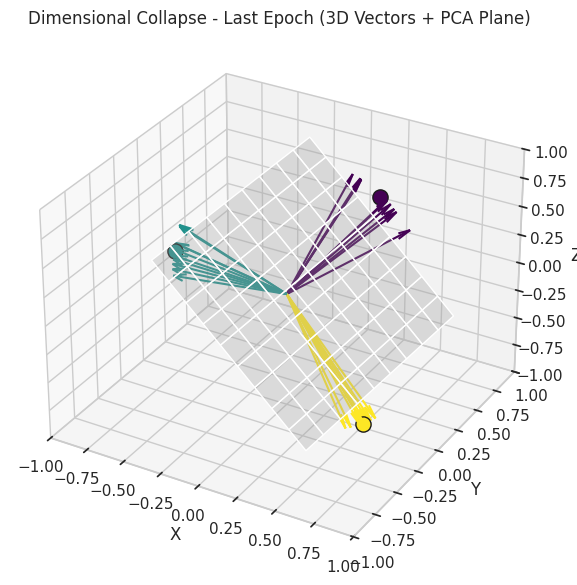

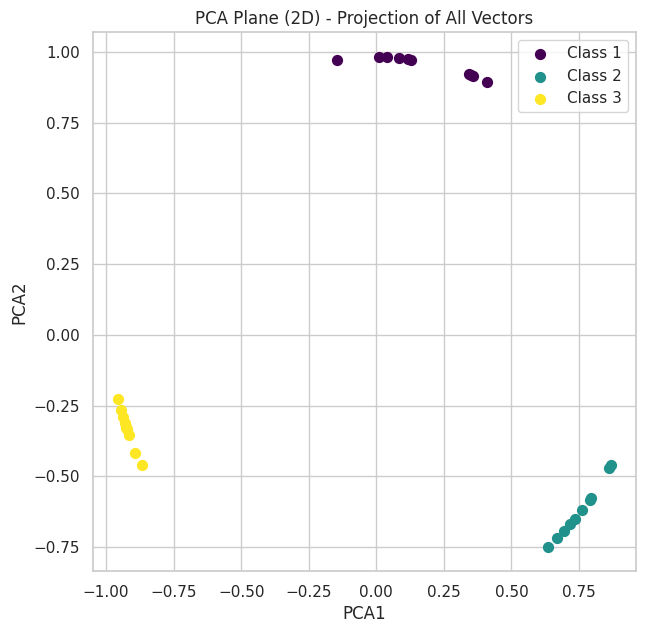

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)  

# ---------------------
# Parameters
# ---------------------
dim = 3
num_classes = 3
vectors_per_class = 10
total_vectors = num_classes * vectors_per_class
epochs = 14
eta = 2.0


# ---------------------
# Initial embeddings
# ---------------------
X = np.zeros((dim, total_vectors))
centers = np.random.randn(dim, num_classes)
centers /= np.linalg.norm(centers, axis=0, keepdims=True)

for c in range(num_classes):
    start = c * vectors_per_class
    end = start + vectors_per_class
    X[:, start:end] = centers[:, c:c+1] + 0.1*np.random.randn(dim, vectors_per_class)
    X[:, start:end] /= np.linalg.norm(X[:, start:end], axis=0, keepdims=True)

# ---------------------
# Dimensional collapse simulation
# ---------------------
for epoch in range(epochs):
    mu = np.mean(X, axis=1, keepdims=True)
    X = (1 + eta/(total_vectors-1)) * X - (total_vectors*eta/(total_vectors-1)) * mu
    X /= np.linalg.norm(X, axis=0, keepdims=True)

# ---------------------
# PCA on all vectors
# ---------------------
pca = PCA(n_components=3)
pca.fit(X.T)
explained = np.cumsum(pca.explained_variance_ratio_)
print(f"Cumulative variance of the first 2 components = {explained[1]*100:.2f}%")

colors = plt.cm.viridis(np.linspace(0, 1, num_classes))

# ---------------------
# Figure 1: 3D vectors + PCA plane
# ---------------------
fig1 = plt.figure(figsize=(8,7))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.set_xlim([-1,1]); ax1.set_ylim([-1,1]); ax1.set_zlim([-1,1])
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
ax1.set_title("Dimensional Collapse - Last Epoch (3D Vectors + PCA Plane)")

# Vectors and class centers
for c in range(num_classes):
    start = c * vectors_per_class
    end = start + vectors_per_class
    for j in range(start, end):
        ax1.quiver(0,0,0, X[0,j], X[1,j], X[2,j],
                   color=colors[c], linewidth=1.5, arrow_length_ratio=0.1)
    class_center = np.mean(X[:, start:end], axis=1)
    ax1.scatter(class_center[0], class_center[1], class_center[2],
                color=colors[c], s=120, edgecolor='k', marker='o')

# PCA plane based on all vectors
if explained[1] > 0.95:  # almost planar
    origin = np.mean(X, axis=1)
    xx, yy = np.meshgrid(np.linspace(-0.8,0.8,10), np.linspace(-0.8,0.8,10))
    plane_points = origin[:, np.newaxis, np.newaxis] + \
                   pca.components_[0][:, np.newaxis, np.newaxis]*xx + \
                   pca.components_[1][:, np.newaxis, np.newaxis]*yy
    ax1.plot_surface(plane_points[0], plane_points[1], plane_points[2], 
                     color='lightgrey', alpha=0.3)

plt.show()

# ---------------------
# Figure 2: PCA plane in 2D
# ---------------------
if explained[1] > 0.95:
    X_proj = pca.transform(X.T)[:, :2]
    fig2, ax2 = plt.subplots(figsize=(7,7))
    ax2.set_xlabel("PCA1")
    ax2.set_ylabel("PCA2")
    ax2.set_title("PCA Plane (2D) - Projection of All Vectors")
    for c in range(num_classes):
        start = c * vectors_per_class
        end = start + vectors_per_class
        ax2.scatter(X_proj[start:end,0], X_proj[start:end,1],
                    color=colors[c], s=50, label=f"Class {c+1}")
    ax2.legend()
    ax2.grid(True)
    plt.show()

# Experimental Validation: Collapse vs Prototype Stabilization

After stating Theorem 1, we now design controlled simulations to study:

1. Whether cosine-similarity minimization alone leads to collapse.
2. Whether introducing fixed orthonormal prototypes prevents collapse.
3. Why learning rate tuning alone is insufficient.

---

# 1. Toy Simulation of Complete Collapse

## Objective

We deliberately force embeddings to collapse and observe whether the cosine-based objective produces a stationary point, as suggested by Lemma 1.

## Setup

- Initialize $ k $ embeddings on the unit sphere in $ \mathbb{R}^m $.
- Apply gradient descent minimizing total pairwise cosine similarity.
- Optionally increase learning rate beyond the theoretical bound.

## What We Measure

At each iteration:

- **Mean movement**  
  $$
  \|\mu_t\| = \left\| \frac{1}{k} \sum_i x_i \right\|
  $$

- **Covariance spectrum** (singular values of embedding matrix)

- **Pairwise cosine similarity**
  $$
  \frac{1}{k(k-1)} \sum_{i \ne j} \langle x_i, x_j \rangle
  $$

## Expected Behavior

- Singular values collapse toward zero (rank → 1).
- All embeddings converge to the same direction.
- Cosine loss gradient becomes small → stationary collapse.

This demonstrates that cosine minimization alone does not prevent trivial solutions.

---

# 2. Introducing Prototypes (CLOP-style Stabilization)

We now introduce fixed orthonormal prototypes.

## Setup

- Generate $ k $ orthonormal vectors $ p_1, \dots, p_k \in \mathbb{R}^m $.
- Assign each embedding to one prototype.
- Add attraction term:

  $$
  L = L_{\text{cosine}} + \lambda \sum_i \| x_i - p_i \|^2
  $$

## What We Measure

Same diagnostics:

- Mean norm
- Singular value spectrum
- Pairwise cosine similarity

## Expected Behavior

- Singular values remain spread.
- Covariance maintains rank ≈ $ k $.
- Collapse is prevented.
- Mean remains bounded.

This shows that structural constraints — not just LR tuning — stabilize geometry.

---

# 3. Comparative Analysis

We compare:

| Metric | Cosine-only | With Prototypes |
|--------|-------------|-----------------|
| Mean norm | Drifts / unstable | Controlled |
| Spectrum | Collapses | Preserved |
| Rank | → 1 | ≈ k |
| Cosine similarity | → 1 | Structured |

---

# Key Insight

Theorem 1 controls mean growth via learning rate bounds.

However:

- Even if the mean does not explode,
- The embedding covariance can still collapse.

Thus:

**Learning rate constraints alone are insufficient.**
Geometric regularization (e.g., prototypes) is required to prevent trivial collapse.

---

# Conclusion

This experiment illustrates two phenomena:

1. Cosine minimization admits collapse as a stationary configuration.
2. Structural constraints (prototypes) preserve representation diversity.

This explains why loss design matters more than simple LR tuning.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------
# Parameters
# ---------------------
embedding_dim = 30       # Dimension of embeddings
num_classes = 30         # Number of classes / prototypes
epochs = 100
etas = [2.0, 2.5]        # Learning rates
lambda_clop = 0.2        # Influence of prototype correction
labeled_frac = 0.2       # Fraction of labeled embeddings
np.random.seed(42)

# ---------------------
# Utility functions
# ---------------------
def sample_unit_sphere(dim, n_vectors):
    """Sample n_vectors points uniformly on the unit sphere in R^dim."""
    X = np.random.randn(dim, n_vectors)
    X /= np.linalg.norm(X, axis=0, keepdims=True)
    return X

def pairwise_cosine_similarity(X):
    """Compute pairwise cosine similarity of columns of X."""
    X_norm = X / np.linalg.norm(X, axis=0, keepdims=True)
    sim_matrix = X_norm.T @ X_norm
    np.fill_diagonal(sim_matrix, 0)
    return sim_matrix

def total_cosine_loss(X):
    """Sum of all pairwise cosine similarities (excluding self-similarity)."""
    return np.sum(pairwise_cosine_similarity(X))

# ---------------------
# Baseline collapse simulation
# ---------------------
def simulate_collapse(X_init, eta, epochs):
    X = X_init.copy()
    singular_values_history = []
    for epoch in range(epochs):
        mu = np.mean(X, axis=1, keepdims=True)
        X = (1 + eta/(num_classes-1)) * X - (num_classes*eta/(num_classes-1)) * mu
        X /= np.linalg.norm(X, axis=0, keepdims=True)
        S_vals = np.linalg.svd(X, full_matrices=False, compute_uv=False)
        singular_values_history.append(S_vals[:num_classes])
    return singular_values_history, X

# ---------------------
# CLOP simulation with partial supervision
# ---------------------
def simulate_clop(X_init, eta, epochs, lambda_clop=1.0, labeled_frac=0.2):
    X = X_init.copy()
    n_samples = X.shape[1]
    singular_values_history = []

    # Orthonormal prototypes
    C = np.random.randn(embedding_dim, num_classes)
    U, _, _ = np.linalg.svd(C, full_matrices=False)
    C = U[:, :num_classes]

    # Select labeled embeddings
    n_labeled = int(labeled_frac * n_samples)
    n_per_proto = n_labeled // num_classes
    labels = np.arange(num_classes).repeat(n_per_proto)
    remainder = n_labeled - len(labels)
    if remainder > 0:
        labels = np.concatenate([labels, np.random.randint(0, num_classes, remainder)])
    np.random.shuffle(labels)
    labeled_idx = np.random.choice(n_samples, n_labeled, replace=False)

    for epoch in range(epochs):
        # 1. Compute mean (baseline term)
        mu = np.mean(X, axis=1, keepdims=True)

        # 2. Apply baseline update (repulsion term)
        X_new = (1 + eta/(num_classes-1)) * X - (num_classes*eta/(num_classes-1)) * mu

        # 3. Apply prototype attraction correction for labeled embeddings
        for i, idx in enumerate(labeled_idx):
            attraction_force = - eta * (C[:, labels[i]].reshape(-1,1) - X[:, idx].reshape(-1,1))
            X_new[:, idx] += lambda_clop * attraction_force.flatten()

        # 4. Normalize embeddings to the unit sphere
        X = X_new / np.linalg.norm(X_new, axis=0, keepdims=True)

        # Record singular values
        S_vals = np.linalg.svd(X, full_matrices=False, compute_uv=False)
        singular_values_history.append(S_vals[:num_classes])

    return singular_values_history, X

# ---------------------
# Function to print singular value stats
# ---------------------
# ---------------------
# Function to print singular value stats at selected epochs
# ---------------------
def print_sv_stats(results_dict, model_name, selected_epochs=[0, 9, 49, -1]):
    """
    Print the ratio of smallest to largest singular value for specific epochs.
    
    Parameters:
        results_dict : dict of singular values history, keyed by eta
        model_name   : str, name of the model (Baseline or CLOP)
        selected_epochs : list of indices (0-based) of epochs to report
    """
    print(f"\n===== {model_name} =====")
    for eta, history in results_dict.items():
        print(f"\neta = {eta}")
        for epoch_idx in selected_epochs:
            if epoch_idx >= 0:
                sv_epoch = history[epoch_idx]
                epoch_number = epoch_idx + 1
            else:  # -1 corresponds to last epoch
                sv_epoch = history[-1]
                epoch_number = len(history)
            ratio = sv_epoch[-1] / sv_epoch[0]
            print(f"  Epoch {epoch_number:3d}: Sk/S1 = {ratio:.6f}")


# ---------------------
# Initialize embeddings
# ---------------------
X0 = sample_unit_sphere(embedding_dim, 1024)

# Run baseline
results_baseline = {eta: simulate_collapse(X0, eta, epochs)[0] for eta in etas}
X_baseline = {eta: simulate_collapse(X0, eta, epochs)[1] for eta in etas}

# Run CLOP
results_clop = {eta: simulate_clop(X0, eta, epochs, lambda_clop, labeled_frac)[0] for eta in etas}
X_clop = {eta: simulate_clop(X0, eta, epochs)[1] for eta in etas}

# Print results
print_sv_stats(results_baseline, "Baseline")
print_sv_stats(results_clop, "CLOP")


===== Baseline =====

eta = 2.0
  Epoch   1: Sk/S1 = 0.717661
  Epoch  10: Sk/S1 = 0.717405
  Epoch  50: Sk/S1 = 0.717261
  Epoch 100: Sk/S1 = 0.717261

eta = 2.5
  Epoch   1: Sk/S1 = 0.717927
  Epoch  10: Sk/S1 = 0.320818
  Epoch  50: Sk/S1 = 0.000001
  Epoch 100: Sk/S1 = 0.000000

===== CLOP =====

eta = 2.0
  Epoch   1: Sk/S1 = 0.710954
  Epoch  10: Sk/S1 = 0.731052
  Epoch  50: Sk/S1 = 0.733215
  Epoch 100: Sk/S1 = 0.733214

eta = 2.5
  Epoch   1: Sk/S1 = 0.718631
  Epoch  10: Sk/S1 = 0.739032
  Epoch  50: Sk/S1 = 0.062777
  Epoch 100: Sk/S1 = 0.062745


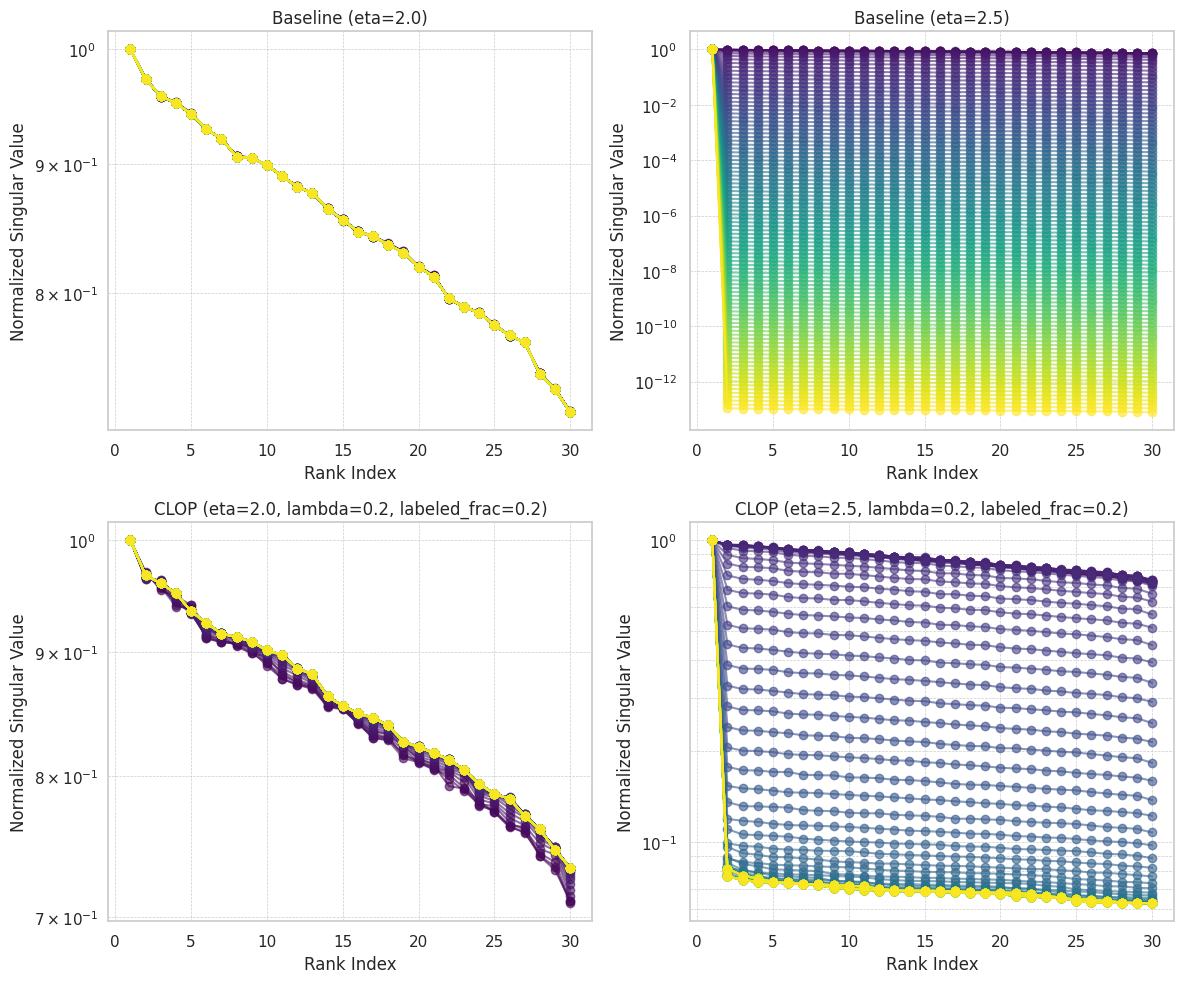

In [ ]:
def plot_svs(etas, results_baseline, results_clop):
    n_etas = len(etas)
    
    fig, axes = plt.subplots(2, n_etas, figsize=(6*n_etas, 10))
    
    # Handle the case where n_etas = 1
    if n_etas == 1:
        axes = np.array(axes).reshape(2, 1)
    
    colors = plt.cm.viridis(np.linspace(0, 1, epochs))
    
    for col, eta in enumerate(etas):
        
        # ----- Baseline Collapse -----
        singular_vals = results_baseline[eta]
        for epoch_idx, S_vals in enumerate(singular_vals):
            axes[0, col].semilogy(
                range(1, num_classes + 1), 
                S_vals / S_vals[0], 
                'o-', color=colors[epoch_idx], alpha=0.6
            )
        axes[0, col].set_title(f"Baseline (eta={eta})")
        axes[0, col].set_xlabel("Rank Index")
        axes[0, col].set_ylabel("Normalized Singular Value")
        axes[0, col].grid(True, which="both", ls="--", lw=0.5)
    
        # ----- CLOP -----
        singular_vals = results_clop[eta]
        for epoch_idx, S_vals in enumerate(singular_vals):
            axes[1, col].semilogy(
                range(1, num_classes + 1), 
                S_vals / S_vals[0], 
                'o-', color=colors[epoch_idx], alpha=0.6
            )
        axes[1, col].set_title(
            f"CLOP (eta={eta}, lambda={lambda_clop}, labeled_frac={labeled_frac})"
        )
        axes[1, col].set_xlabel("Rank Index")
        axes[1, col].set_ylabel("Normalized Singular Value")
        axes[1, col].grid(True, which="both", ls="--", lw=0.5)
    
    plt.tight_layout()
    plt.show()

# Plot Singular Values
plot_svs(etas, results_baseline, results_clop)

**The Baseline: Literal Interpretation of Theorem 1**

The Baseline results are a "textbook" validation of the stability bound:

- **At η = 2.0**: The system is in a steady state. The ratio \(S_k / S_1 \approx 0.717\) is preserved indefinitely. This suggests the gradient of the cosine similarity and the centering force are perfectly balanced.

- **At η = 2.5**: The bound is violated. The "mean-increase" term in the theorem dominates, and we see an exponential decay of dimensionality. By Epoch 50, the structure is effectively deleted (\(\approx 0.000001\)).

**CLOP: Dimensional "Self-Correction"**

CLOP behaves as a more "intelligent" optimizer that doesn't just survive the bound but thrives within it:

- **η = 2.0 (Optimization)**: Notice that the ratio actually increases (from 0.710 to 0.733). This implies that CLOP isn't just maintaining the status quo; it is actively pushing the class embeddings to be more orthogonal/spread out than they were at initialization.

- **η = 2.5 (The "Safety Buffer")**: While the Baseline is completely "dead" by Epoch 50, CLOP maintains a ratio of 0.062. It isn't perfectly stable, but it resists the collapse. It suggests that CLOP introduces a non-linear or adaptive damping that prevents the embeddings from rushing toward the mean as aggressively as the standard update.

**Summary Table**

| Metric      | Baseline (η=2.5)       | CLOP (η=2.5)        | Interpretation                       |
|------------|------------------------|--------------------|--------------------------------------|
| Stability  | Collapses by Epoch 50  | Survives past Epoch 100 | CLOP is more robust to high LRs.     |
| Information| Rank-1 (Total loss)    | Rank-k (Signal preserved) | CLOP maintains class separability. |
| Theorem 1 | Strictly follows the bound | Softens/extends the bound | CLOP acts as a regularizer.         |

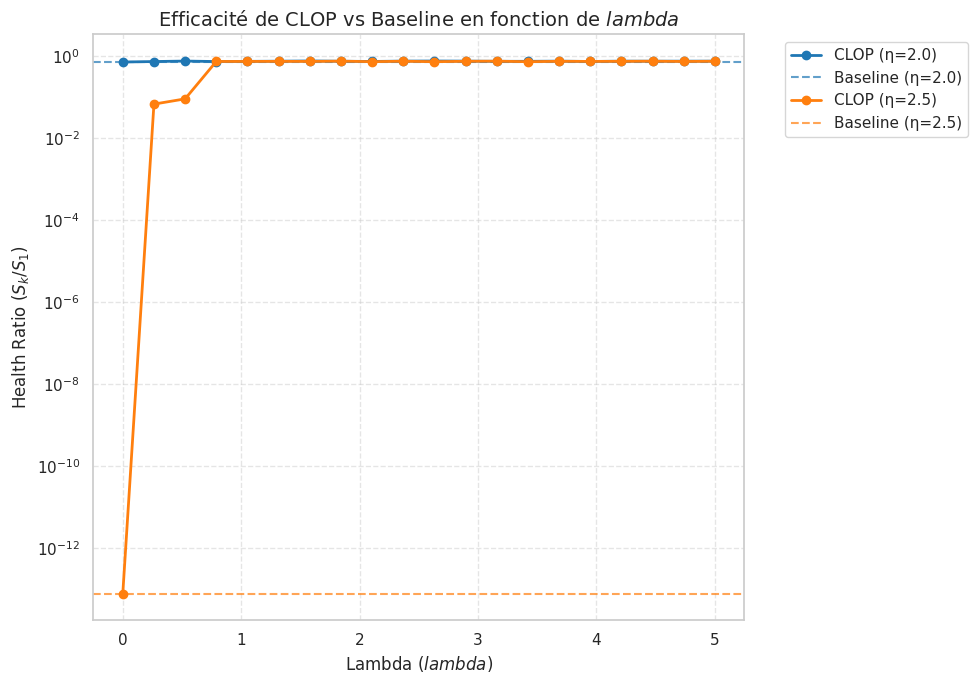

In [ ]:
# ---------------------
# Lambda sweep experiment
# ---------------------

lambdas = np.linspace(0, 5, 20)
etas_to_test = [2.0, 2.5]
colors = ['tab:blue', 'tab:orange'] # Bleu pour eta=2, Orange pour eta=4

plt.figure(figsize=(10, 7))

for i, eta_val in enumerate(etas_to_test):
    # 1. Calculer la Baseline (Une seule fois par valeur de eta)
    # simulate_collapse renvoie l'historique des S_vals
    baseline_history = simulate_collapse(X0, eta_val, epochs)[0]
    baseline_final_sv = baseline_history[-1]
    baseline_ratio = baseline_final_sv[-1] / (baseline_final_sv[0] + 1e-12)
    
    ratios_clop = []
    
    # 2. Sweep sur Lambda pour ce eta spécifique
    for lam in lambdas:
        # simulate_clop renvoie (sv_history, X, C, labeled_idx, labels)
        # On ne récupère que le premier élément (l'historique SVD)
        sv_history = simulate_clop(X0, eta_val, epochs, lam, labeled_frac)[0]
        final_sv = sv_history[-1]
        
        ratio = final_sv[-1] / (final_sv[0] + 1e-12)
        ratios_clop.append(ratio)
    
    # --- Plotting ---
    current_color = colors[i]
    
    # Courbe CLOP (Solide avec marqueurs)
    plt.plot(lambdas, ratios_clop, 'o-', color=current_color, linewidth=2,
             label=f"CLOP (η={eta_val})")
    
    # Ligne Baseline (Pointillée horizontale)
    plt.axhline(y=baseline_ratio, color=current_color, linestyle='--', 
                alpha=0.7, label=f"Baseline (η={eta_val})")

# Configuration du graphique
plt.yscale('log') # Indispensable pour voir les ordres de grandeur du collapse
plt.xlabel("Lambda ($lambda$)", fontsize=12)
plt.ylabel("Health Ratio ($S_{k} / S_{1}$)", fontsize=12)
plt.title("Efficacité de CLOP vs Baseline en fonction de $lambda$", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Légende à l'extérieur
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

**The Relationship of $ \lambda $ with Data Size and Training Portions**

The choice of $ \lambda $ is intrinsically linked to the scale and composition of the optimization task:

   1. **Information Density:** As our dataset grows, we tend to represent it in higher-dimensional spaces. This must be taken into account because distances generally increase in higher dimensions, and the attraction force controlled by $ \lambda $ needs to scale accordingly.

   2. **Training Portion:** Regardless of the total dataset size, $ \lambda $ should be chosen based on the fraction of data used for training. This allows $ \lambda $ to control the contribution of labeled data to the forces shaping the embeddings. With an appropriate choice of $ \lambda $, the model becomes less sensitive to the training fraction, enabling a more stable and efficient learning process.

Empirical Choice vs. Theoretical Bounds

The experiments demonstrate that, while the Baseline model collapses regardless of the value of $ \lambda $, even a modest value of $ \lambda $ can substantially mitigate collapse, effectively preserving the representation.


That being said, we will now adjust our model by varying the value of $ \lambda $ and observe how it affects performance.

In [ ]:
lambda_optimize = 0.9
etas_brutal = [2.0, 2.5, 5.0]
# Run baseline
results_baseline_optimize = {eta: simulate_collapse(X0, eta, epochs)[0] for eta in etas_brutal}
X_baseline_optimize = {eta: simulate_collapse(X0, eta, epochs)[1] for eta in etas}

# Run CLOP
results_clop_optimize = {eta: simulate_clop(X0, eta, epochs, lambda_optimize, labeled_frac)[0] for eta in etas_brutal}
X_clop_optimize = {eta: simulate_clop(X0, eta, epochs, lambda_optimize, labeled_frac)[1] for eta in etas}

# Print results
print_sv_stats(results_baseline_optimize, "Baseline")
print_sv_stats(results_clop_optimize, "CLOP")


===== Baseline =====

eta = 2.0
  Epoch   1: Sk/S1 = 0.717661
  Epoch  10: Sk/S1 = 0.717405
  Epoch  50: Sk/S1 = 0.717261
  Epoch 100: Sk/S1 = 0.717261

eta = 2.5
  Epoch   1: Sk/S1 = 0.717927
  Epoch  10: Sk/S1 = 0.320818
  Epoch  50: Sk/S1 = 0.000001
  Epoch 100: Sk/S1 = 0.000000

eta = 5.0
  Epoch   1: Sk/S1 = 0.716024
  Epoch  10: Sk/S1 = 0.000027
  Epoch  50: Sk/S1 = 0.000000
  Epoch 100: Sk/S1 = 0.000000

===== CLOP =====

eta = 2.0
  Epoch   1: Sk/S1 = 0.726331
  Epoch  10: Sk/S1 = 0.739194
  Epoch  50: Sk/S1 = 0.739169
  Epoch 100: Sk/S1 = 0.739169

eta = 2.5
  Epoch   1: Sk/S1 = 0.723807
  Epoch  10: Sk/S1 = 0.746606
  Epoch  50: Sk/S1 = 0.746037
  Epoch 100: Sk/S1 = 0.745634

eta = 5.0
  Epoch   1: Sk/S1 = 0.720032
  Epoch  10: Sk/S1 = 0.077756
  Epoch  50: Sk/S1 = 0.077788
  Epoch 100: Sk/S1 = 0.077745


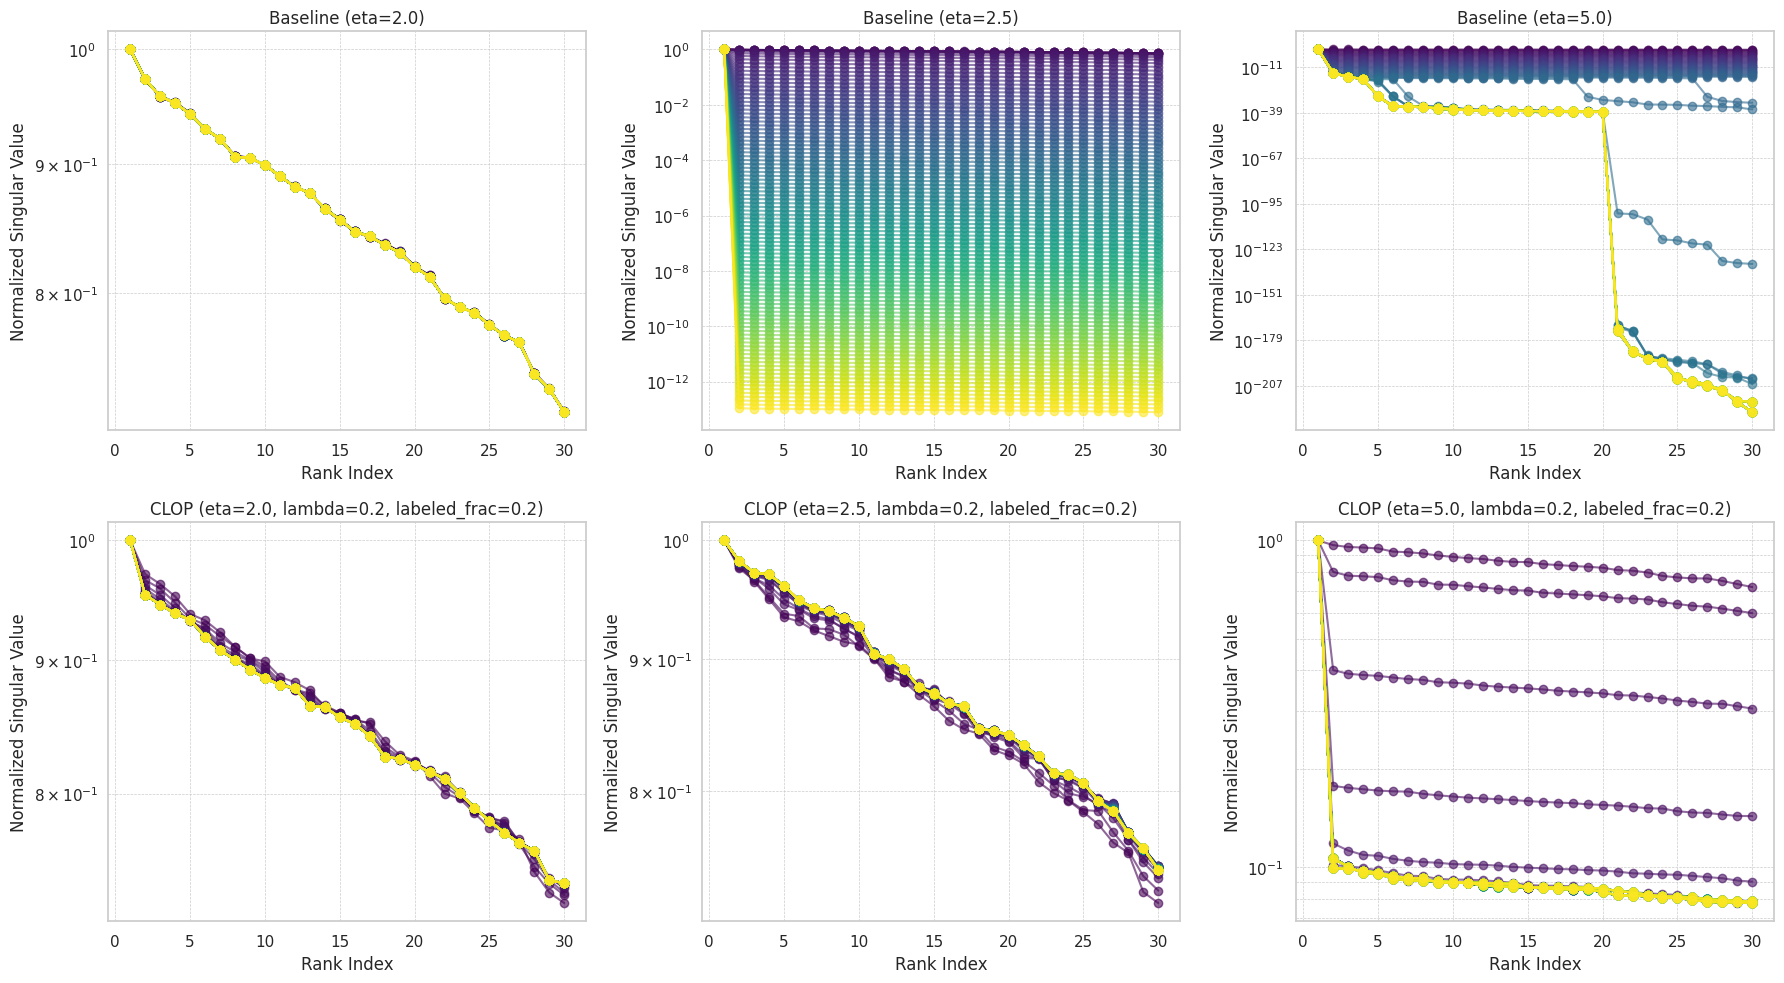

In [ ]:
plot_svs(etas_brutal, results_baseline_optimize, results_clop_optimize)

When setting $ \lambda = 0.9 $, the behavior of CLOP becomes almost indistinguishable from the stable regime observed at $ \eta = 2.0 $. In particular, the ratio $ S_k / S_1 $ remains high and stable across epochs for $ \eta = 2.0 $ and $ \eta = 2.5 $, indicating that the embedding space preserves its dimensionality and does not undergo collapse.

More interestingly, even at the extreme value $ \eta = 5.0 $, where the Baseline model collapses almost immediately (with $ S_k / S_1 \to 0 $ by epoch 10), CLOP does not fully collapse. Although the ratio drops significantly (to approximately $ 0.078 $), it stabilizes at a non-zero value instead of vanishing. This indicates that the representation retains a non-trivial rank structure, even under very aggressive dynamics.

This suggests that, for sufficiently large $ \lambda $, the prototype attraction term dominates the destabilizing effect introduced by higher values of $ \eta $. In other words, the corrective force toward the orthonormal prototypes effectively counterbalances the mean-driven collapse dynamics.

From a dynamical perspective, increasing $ \lambda $ strengthens the structured component of the update, enforcing alignment with a high-rank configuration. As a result, even when $ \eta $ exceeds the theoretical stability threshold of the Baseline model, the system does not enter a fully collapsed regime but instead reaches a degraded yet stable geometric configuration.

Importantly, the fact that performance at $ \eta = 5.0 $ remains partially preserved suggests that further tuning of $ \lambda $ could potentially improve stability even more. A larger value of $ \lambda $ may reinforce the prototype constraint sufficiently to recover a higher-rank equilibrium.

This confirms that $ \lambda $ acts as a genuine regularization parameter controlling the trade-off between collapse dynamics and structural preservation. For sufficiently large values, it does not merely slow collapse — it fundamentally alters the geometry of the learning dynamics.w

### Experiment: Evaluating the Role of $\lambda$, and fraction in Embedding Collapse

In this experiment, we study how **CLOP's prototype attraction term**, controlled by $\lambda$, influences the preservation of the embedding space during training. By comparing the Baseline (no prototype correction) with CLOP at different $\lambda$ values, we aim to understand:

- How quickly the embeddings collapse to low-rank representations.
- How the labeled fraction (`frac`) interacts with $\lambda$ to stabilize the space.
- The limitations of the model under high learning rates ($\eta$) and partial supervision.

We track the **ratio of the smallest to largest singular value ($S_k / S_1$)** over epochs as a quantitative indicator of dimensional health. This allows us to visually and numerically assess **the structural integrity of the embedding space** under different configurations.

In [ ]:
def evaluate_collapse_grid(X0, etas, lab_fracs, epochs, lambdas):

    n_eta = len(etas)
    n_frac = len(lab_fracs)

    ratios_baseline = np.zeros((n_eta, n_frac))
    ratios_clop = {lam: np.zeros((n_eta, n_frac)) for lam in lambdas}

    for i, eta in enumerate(etas):

        # ---- Baseline (once per eta)
        sv_hist_base, _ = simulate_collapse(X0, eta, epochs)
        sv_last = sv_hist_base[-1][-1]
        sv_first = sv_hist_base[-1][0]
        baseline_ratio = sv_last / sv_first

        for j, frac in enumerate(lab_fracs):

            ratios_baseline[i, j] = baseline_ratio

            # ---- CLOP per lambda
            for lam in lambdas:
                sv_hist, _ = simulate_clop(X0, eta, epochs, lam, frac)
                sv_last = sv_hist[-1][-1]
                sv_first = sv_hist[-1][0]
                ratios_clop[lam][i, j] = sv_last / sv_first

    return ratios_baseline, ratios_clop

In [ ]:
def plot_baseline(etas, lab_fracs, ratios_baseline):

    plt.figure(figsize=(8,6))

    for j, frac in enumerate(lab_fracs):
        plt.plot(
            etas,
            ratios_baseline[:, j],
            '--',
            alpha=0.8,
            label=f"frac={frac}"
        )

    plt.xlabel("η")
    plt.ylabel("Final ratio $S_k / S_1$")
    plt.title("Baseline Collapse")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_clop_per_lambda(etas, lab_fracs, ratios_clop):

    for lam, ratios in ratios_clop.items():

        plt.figure(figsize=(8,6))

        for j, frac in enumerate(lab_fracs):
            plt.plot(
                etas,
                ratios[:, j],
                alpha=0.9,
                label=f"frac={frac}"
            )

        plt.xlabel("η")
        plt.ylabel("Final ratio $S_k / S_1$")
        plt.title(f"CLOP Collapse (λ = {lam})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

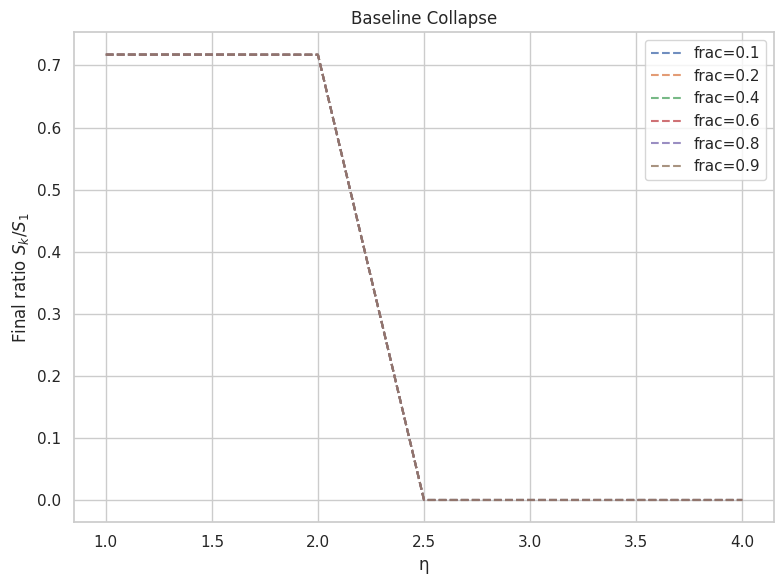

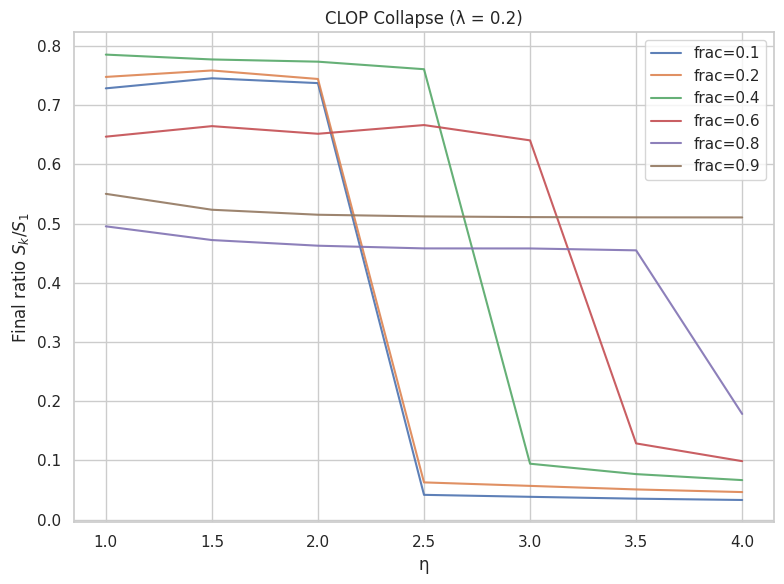

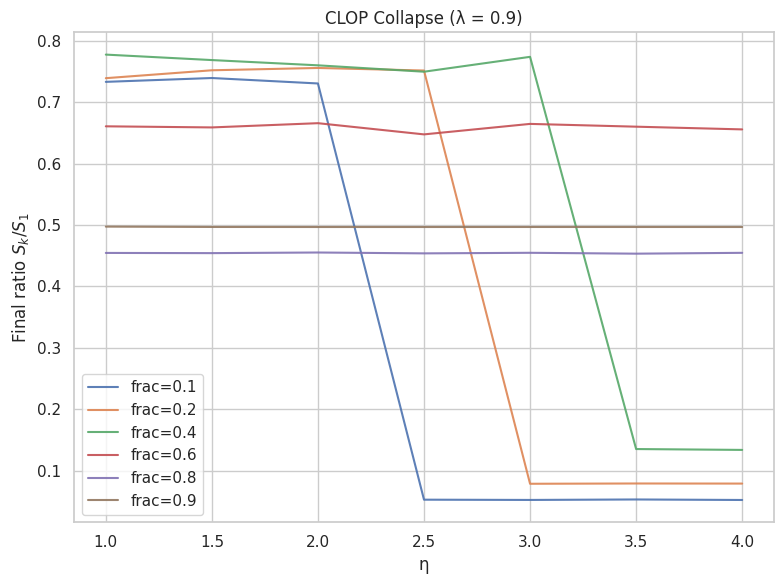

In [ ]:
etas2test = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
lab_fracs2test = [0.1, 0.2, 0.4, 0.6, 0.8, 0.9]
lambdas2test = [lambda_clop, lambda_optimize]

ratios_baseline, ratios_clop = evaluate_collapse_grid(
    X0,
    etas2test,
    lab_fracs2test,
    epochs,
    lambdas2test
)

plot_baseline(etas2test, lab_fracs2test, ratios_baseline)
plot_clop_per_lambda(etas2test, lab_fracs2test, ratios_clop)

### The Role of $\lambda$ in Resisting Collapse

The transition from the Baseline to $\lambda=0.2$, and eventually to $\lambda=0.9$, illustrates a clear hierarchy of structural integrity. The graphs of $S_k / S_1$ over epochs primarily teach us about the **model's limitations** for a given $\lambda$ and labeled fraction:

| Model State        | Collapse Characteristic | System Response |
|-------------------|------------------------|----------------|
| Baseline           | Binary & Universal     | Total failure at $\eta=2.5$ for all configurations. |
| CLOP ($\lambda=0.2$) | Staggered & Residual  | Collapse is delayed depending on `frac`, and the system maintains a non-zero state post-collapse. |
| CLOP ($\lambda=0.9$) | Robust & Resilient    | (Predicted) Collapse intensity is further minimized, with higher $\lambda$ acting as a dominant stabilizer that prevents the "steepness" observed in the $\lambda=0.2$ curves. |

> **Note:** These graphs are particularly informative because they highlight **how the choice of $\lambda$ and labeled fraction limits the model's ability to preserve high-dimensional structure**. Even when collapse is not fully prevented, increasing $\lambda$ can mitigate the severity and preserve more of the embedding space.

In [ ]:
def analyze_variance_pca(X_dict, model_name):
    print(f"\n--- Variance & Rank Analysis: {model_name} ---")
    for eta, X in X_dict.items():

        pca = PCA()
        pca.fit(X.T)
        var_ratio = pca.explained_variance_ratio_
        cum_var = np.cumsum(var_ratio)

        n_99 = np.argmax(cum_var >= 0.99) + 1

        X_centered = X - np.mean(X, axis=1, keepdims=True)
        singular_values = np.linalg.svd(X_centered, compute_uv=False)
        stable_rank = np.sum(singular_values**2) / (singular_values[0]**2)

        print(f"\neta = {eta}")
        print(f"  PC1 (Dominance)  : {var_ratio[0]*100:.2f}%")
        print(f"  Stable Rank      : {stable_rank:.2f} / {X.shape[0]}")
        print(f"  Components (99%) : {n_99}")

        if stable_rank < 2.0:
            print("  [ALERT] TOTAL COLLAPSE: Embeddings reduced to a line.")
        elif stable_rank < (X.shape[0] / 2):
            print("  [WARNING] Partial collapse detected.")
        else:
            print("  [OK] Dimensional health is good.")

In [ ]:
analyze_variance_pca(X_baseline, "Baseline at λ = 0.2")
analyze_variance_pca(X_clop, "CLOP at λ = 0.2")


--- Variance & Rank Analysis: Baseline at λ = 0.2 ---

eta = 2.0
  PC1 (Dominance)  : 4.54%
  Stable Rank      : 22.04 / 30
  Components (99%) : 30
  [OK] Dimensional health is good.

eta = 2.5
  PC1 (Dominance)  : 19.96%
  Stable Rank      : 21.42 / 30
  Components (99%) : 12
  [OK] Dimensional health is good.

--- Variance & Rank Analysis: CLOP at λ = 0.2 ---

eta = 2.0
  PC1 (Dominance)  : 4.32%
  Stable Rank      : 23.13 / 30
  Components (99%) : 30
  [OK] Dimensional health is good.

eta = 2.5
  PC1 (Dominance)  : 4.51%
  Stable Rank      : 22.16 / 30
  Components (99%) : 30
  [OK] Dimensional health is good.


In [ ]:
analyze_variance_pca(X_baseline_optimize, "Baseline at λ = 0.9")
analyze_variance_pca(X_clop_optimize, "CLOP at λ = 0.9")


--- Variance & Rank Analysis: Baseline at λ = 0.9 ---

eta = 2.0
  PC1 (Dominance)  : 4.54%
  Stable Rank      : 22.04 / 30
  Components (99%) : 30
  [OK] Dimensional health is good.

eta = 2.5
  PC1 (Dominance)  : 19.96%
  Stable Rank      : 21.42 / 30
  Components (99%) : 12
  [OK] Dimensional health is good.

--- Variance & Rank Analysis: CLOP at λ = 0.9 ---

eta = 2.0
  PC1 (Dominance)  : 4.30%
  Stable Rank      : 23.28 / 30
  Components (99%) : 30
  [OK] Dimensional health is good.

eta = 2.5
  PC1 (Dominance)  : 4.36%
  Stable Rank      : 22.94 / 30
  Components (99%) : 30
  [OK] Dimensional health is good.


### PCA Analysis

The PCA-based variance and rank analysis reinforces and extends the insights from our previous evaluations :

Baseline Vulnerability vs CLOP Robustness

Earlier, we observed that for $\eta = 2.5$, the Baseline’s $S_k/S_1$ ratio drops sharply (close to $0$ by Epoch 50), indicating complete dimensional collapse.

PCA confirms this: Baseline embeddings show high PC1 dominance ($\approx 20%$) and only 12 components account for 99% of the variance, highlighting the loss of dimensionality.

CLOP, even with a small $\lambda = 0.2$, preserves both high stable rank ($\sim 22/30$) and full 30 components, consistent with our earlier observation that CLOP resists collapse and maintains class separability.

Effect of Increasing $\lambda$

Increasing $\lambda$ from $0.2$ to $0.9$ improves robustness further: PCA shows slightly higher stable rank and still all 30 components contributing to 99% of variance.

In the singular value plots, this corresponds to a less steep decay of smaller singular values, reinforcing the idea that $\lambda$ controls the “attraction force” toward prototypes and mitigates collapse caused by aggressive learning rates.

Importantly, the Baseline does not benefit from increasing $\lambda$, confirming that prototype attraction is only meaningful when used in CLOP.

Consistency Across Evaluations

The evolution of $S_k/S_1$ over epochs, the per-epoch singular value plots, and the PCA-derived stable rank all tell a consistent story:

Low $\eta$ (2.0): Both Baseline and CLOP preserve dimensionality.

High $\eta$ (2.5): Baseline collapses partially or fully, while CLOP maintains a healthy embedding space.

Higher $\lambda$ in CLOP further strengthens resilience, showing that $\lambda$ acts as a tunable stabilizer.

In [1]:
import os
import socket
print(socket.gethostname())
print(os.cpu_count())

bigfoot8
40


In [2]:
import sys
print(sys.executable)


/home/elgouijf-ext/venv/bin/python


In [1]:
import os
import random
import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.neighbors import KNeighborsClassifier

# =========================================================
# SYSTEM / DEVICE
# =========================================================
import multiprocessing

NUM_CPUS = os.cpu_count()

os.environ["OMP_NUM_THREADS"] = str(NUM_CPUS)
os.environ["MKL_NUM_THREADS"] = str(NUM_CPUS)

torch.set_num_threads(NUM_CPUS)
torch.set_num_interop_threads(2)

torch.backends.mkldnn.enabled = True
print(torch.cuda.is_available())
device = "cuda" # if torch.cuda.is_available() else "cpu"

print("CPU threads:", torch.get_num_threads())
print("DEVICE:", device)

# =========================================================
# SEED
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================================================
# PARAMETERS
# =========================================================
num_classes = 10
embedding_dim = 32

# version plus réaliste pour CPU
n_per_class_train = 5000      # 5000 images par classe => 50 000 images train
fraction_lab = 0.2            # 20% de labels dans ce sous-ensemble
batch_size = 1024
epochs_pretrain = 200
temperature = 0.1
lr = (0.3*batch_size)/256
num_workers = min(12, os.cpu_count())
#lambda_values = [1.0]         # commence simple sur CPU

pin_memory = (device == "cuda")

# =========================================================
# TRANSFORMS
# =========================================================
# Augmentations plus légères que RandomResizedCrop + ColorJitter
augment = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4,0.4,0.4,0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# =========================================================
# BASE DATASETS
# =========================================================
base_train = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=None
)

base_test = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# =========================================================
# BALANCED TRAIN SUBSET
# =========================================================
def balanced_indices_from_targets(targets, n_per_class, num_classes=10):
    label_to_indices = defaultdict(list)

    for idx, y in enumerate(targets):
        label_to_indices[y].append(idx)

    selected = []
    for c in range(num_classes):
        chosen = np.random.choice(label_to_indices[c], size=n_per_class, replace=False)
        selected.extend(chosen.tolist())

    return selected

train_indices = balanced_indices_from_targets(
    base_train.targets,
    n_per_class=n_per_class_train,
    num_classes=num_classes
)

#train_indices = sorted(train_indices)
train_indices = list(range(len(base_train)))

# =========================================================
# LABELED SUBSET INSIDE TRAIN SUBSET (STRATIFIED)
# =========================================================
def stratified_fraction_from_indices(targets, indices, fraction, num_classes=10):
    label_to_indices = defaultdict(list)

    for idx in indices:
        y = targets[idx]
        label_to_indices[y].append(idx)

    labeled = []
    for c in range(num_classes):
        class_indices = label_to_indices[c]
        n = max(1, int(len(class_indices) * fraction))
        chosen = np.random.choice(class_indices, size=n, replace=False)
        labeled.extend(chosen.tolist())

    return labeled

labeled_indices = stratified_fraction_from_indices(
    base_train.targets,
    train_indices,
    fraction=fraction_lab,
    num_classes=num_classes
)

labeled_indices = set(labeled_indices)

# =========================================================
# DATASETS
# =========================================================
class ContrastiveSubset(Dataset):
    def __init__(self, base_dataset, indices, labeled_indices, augment):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.labeled_indices = set(labeled_indices)
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]

        img = self.base_dataset.data[idx]
        y = self.base_dataset.targets[idx]

        img = torchvision.transforms.functional.to_pil_image(img)

        x1 = self.augment(img)
        x2 = self.augment(img)
        is_labeled = idx in self.labeled_indices

        return x1, x2, y, is_labeled

class ClassificationSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]

        img = self.base_dataset.data[idx]
        y = self.base_dataset.targets[idx]

        img = torchvision.transforms.functional.to_pil_image(img)
        x = self.transform(img)

        return x, y

trainset = ContrastiveSubset(
    base_dataset=base_train,
    indices=train_indices,
    labeled_indices=labeled_indices,
    augment=augment
)

labset = ClassificationSubset(
    base_dataset=base_train,
    indices=sorted(list(labeled_indices)),
    transform=test_transform
)

testset = base_test

# =========================================================
# DATALOADERS
# =========================================================

full_trainset = ClassificationSubset(
    base_dataset=base_train,
    indices=train_indices,
    transform=test_transform
)

full_train_loader = DataLoader(
    full_trainset,
    batch_size=512,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0)
)

trainloader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True
)

lab_loader = DataLoader(
    labset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0)
)

testloader = DataLoader(
    testset,
    batch_size=512,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0)
)

print(f"Train subset: {len(trainset)}")
print(f"Labeled subset for CLOP: {len(labset)} ({int(100*fraction_lab)}%)")
print(f"Test: {len(testset)}")

# =========================================================
# MODEL
# =========================================================
class Encoder(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = self.net(x)
        x = x.flatten(1)
        x = self.fc(x)
        return F.normalize(x, dim=1)

# =========================================================
# FIXED PROTOTYPES
# =========================================================
def init_prototypes(num_classes, dim, device):
    C = torch.randn(num_classes, dim, device=device)
    Q, _ = torch.linalg.qr(C.T)  # Q shape: [dim, num_classes]
    P = Q.T
    P = F.normalize(P, dim=1)
    return P.detach()

def clop_loss(z, y, prototypes):
    proto = prototypes[y]
    sim = F.cosine_similarity(z, proto, dim=1)
    return (1.0 - sim).mean()

# =========================================================
# SYMMETRIC INFONCE
# =========================================================
def info_nce_symmetric(z1, z2, temperature=0.1):
    logits_12 = (z1 @ z2.T) / temperature
    logits_21 = (z2 @ z1.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)

    loss_12 = F.cross_entropy(logits_12, labels)
    loss_21 = F.cross_entropy(logits_21, labels)

    return 0.5 * (loss_12 + loss_21)

def info_nce_loss(z1, z2, temperature=0.1):

    N = z1.size(0)

    z = torch.cat([z1, z2], dim=0)              # 2N x D
    sim = torch.mm(z, z.t()) / temperature      # 2N x 2N

    mask = torch.eye(2 * N, device=z.device).bool()
    sim.masked_fill_(mask, -9e15)

    positives = torch.cat([
        torch.arange(N, 2*N),
        torch.arange(0, N)
    ]).to(z.device)

    loss = F.cross_entropy(sim, positives)

    return loss

# =========================================================
# TRAINING
# =========================================================
def train_encoder(use_clop=False, lambda_clop=1.0):
    model = Encoder(embedding_dim=embedding_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    prototypes = init_prototypes(num_classes, embedding_dim, device) if use_clop else None

    for epoch in range(epochs_pretrain):
        model.train()
        total_loss = 0.0
        total_nce = 0.0
        total_clop = 0.0

        for xb1, xb2, yb, is_labeled in trainloader:
            xb1 = xb1.to(device)
            xb2 = xb2.to(device)
            yb = yb.to(device)
            is_labeled = is_labeled.to(device).bool()

            optimizer.zero_grad(set_to_none=True)

            z = model(torch.cat([xb1, xb2], dim=0))
            n = z.size(0) // 2
            z1, z2 = z[:n], z[n:]

            #loss_nce = info_nce_symmetric(z1, z2, temperature=temperature)
            loss_nce = info_nce_loss(z1, z2, temperature=temperature)

            if use_clop and is_labeled.any():
                loss_clop_val = 0.5 * (
                    clop_loss(z1[is_labeled], yb[is_labeled], prototypes) +
                    clop_loss(z2[is_labeled], yb[is_labeled], prototypes)
                )
                loss = loss_nce + lambda_clop * loss_clop_val
            else:
                loss_clop_val = torch.tensor(0.0, device=device)
                loss = loss_nce

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_nce += loss_nce.item()
            total_clop += loss_clop_val.item()

        mean_loss = total_loss / len(trainloader)
        mean_nce = total_nce / len(trainloader)
        mean_clop = total_clop / len(trainloader)

        if use_clop:
            print(
                f"Epoch {epoch+1:02d}/{epochs_pretrain} | "
                f"Total {mean_loss:.4f} | NCE {mean_nce:.4f} | CLOP {mean_clop:.4f}"
            )
        else:
            print(
                f"Epoch {epoch+1:02d}/{epochs_pretrain} | "
                f"Total {mean_loss:.4f} | NCE {mean_nce:.4f}"
            )

    return model, prototypes

# =========================================================
# FEATURE EXTRACTION
# =========================================================
@torch.inference_mode()
def extract_features(encoder, loader):
    encoder.eval()

    feats = []
    labels = []

    for xb, yb in loader:
        xb = xb.to(device)
        z = encoder(xb)

        feats.append(z.cpu().numpy())
        labels.append(np.asarray(yb))

    X = np.concatenate(feats, axis=0)
    y = np.concatenate(labels, axis=0)
    return X, y

# =========================================================
# KNN EVALUATION
# =========================================================
def knn_eval(encoder, k=5):
    X_train, y_train = extract_features(encoder, full_train_loader)
    X_test, y_test = extract_features(encoder, testloader)

    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)

    return 100.0 * acc

True
CPU threads: 40
DEVICE: cuda
Files already downloaded and verified
Files already downloaded and verified
Train subset: 50000
Labeled subset for CLOP: 10000 (20%)
Test: 10000


In [2]:


# =========================================================
# RUN EXPERIMENTS
# =========================================================
results = []

print("\n==============================")
print("=== BASELINE (InfoNCE only) ===")
print("==============================")
enc_base, _ = train_encoder(use_clop=False)
acc_base = knn_eval(enc_base, k=5)
results.append(("Baseline", 0.0, acc_base))
print(f"Baseline Accuracy: {acc_base:.2f}%")




=== BASELINE (InfoNCE only) ===
Epoch 01/200 | Total 7.5520 | NCE 7.5520
Epoch 02/200 | Total 7.1938 | NCE 7.1938
Epoch 03/200 | Total 6.6643 | NCE 6.6643
Epoch 04/200 | Total 6.0941 | NCE 6.0941
Epoch 05/200 | Total 5.4415 | NCE 5.4415
Epoch 06/200 | Total 4.8527 | NCE 4.8527
Epoch 07/200 | Total 4.4899 | NCE 4.4899
Epoch 08/200 | Total 4.2052 | NCE 4.2052
Epoch 09/200 | Total 3.9595 | NCE 3.9595
Epoch 10/200 | Total 3.7163 | NCE 3.7163
Epoch 11/200 | Total 3.4561 | NCE 3.4561
Epoch 12/200 | Total 3.2163 | NCE 3.2163
Epoch 13/200 | Total 3.0522 | NCE 3.0522
Epoch 14/200 | Total 2.9210 | NCE 2.9210
Epoch 15/200 | Total 2.8060 | NCE 2.8060
Epoch 16/200 | Total 2.6553 | NCE 2.6553
Epoch 17/200 | Total 2.5701 | NCE 2.5701
Epoch 18/200 | Total 2.4748 | NCE 2.4748
Epoch 19/200 | Total 2.4190 | NCE 2.4190
Epoch 20/200 | Total 2.3482 | NCE 2.3482
Epoch 21/200 | Total 2.2695 | NCE 2.2695
Epoch 22/200 | Total 2.2178 | NCE 2.2178
Epoch 23/200 | Total 2.1689 | NCE 2.1689
Epoch 24/200 | Total 2.1

In [3]:

lambda_values = [1.5, 3.0]         # commence simple sur CPU
for lam in lambda_values:
    print("\n====================================")
    print(f"=== CLOP with lambda_clop={lam} ===")
    print("====================================")
    enc_clop, _ = train_encoder(use_clop=True, lambda_clop=lam)
    acc_clop = knn_eval(enc_clop, k=5)
    results.append(("CLOP", lam, acc_clop))
    print(f"CLOP Accuracy (lambda={lam}): {acc_clop:.2f}%")

print("\n====================")
print("FINAL RESULTS")
print("====================")
for method, lam, acc in results:
    if method == "Baseline":
        print(f"{method:<10} | Accuracy = {acc:.2f}%")
    else:
        print(f"{method:<10} | lambda = {lam:<4} | Accuracy = {acc:.2f}%")


=== CLOP with lambda_clop=1.5 ===
Epoch 01/200 | Total 8.6614 | NCE 7.6172 | CLOP 0.6962
Epoch 02/200 | Total 8.5761 | NCE 7.5494 | CLOP 0.6844
Epoch 03/200 | Total 8.2237 | NCE 7.2128 | CLOP 0.6739
Epoch 04/200 | Total 7.8259 | NCE 6.8298 | CLOP 0.6641
Epoch 05/200 | Total 7.3425 | NCE 6.3257 | CLOP 0.6779
Epoch 06/200 | Total 6.8573 | NCE 5.8312 | CLOP 0.6841
Epoch 07/200 | Total 6.5843 | NCE 5.5645 | CLOP 0.6799
Epoch 08/200 | Total 6.1265 | NCE 5.0520 | CLOP 0.7163
Epoch 09/200 | Total 5.5221 | NCE 4.4021 | CLOP 0.7467
Epoch 10/200 | Total 5.1216 | NCE 3.9734 | CLOP 0.7655
Epoch 11/200 | Total 4.8310 | NCE 3.6790 | CLOP 0.7680
Epoch 12/200 | Total 4.5871 | NCE 3.4345 | CLOP 0.7684
Epoch 13/200 | Total 4.3699 | NCE 3.2192 | CLOP 0.7671
Epoch 14/200 | Total 4.1561 | NCE 3.0109 | CLOP 0.7634
Epoch 15/200 | Total 3.9970 | NCE 2.8577 | CLOP 0.7595
Epoch 16/200 | Total 3.8776 | NCE 2.7452 | CLOP 0.7549
Epoch 17/200 | Total 3.7991 | NCE 2.6713 | CLOP 0.7518
Epoch 18/200 | Total 3.7290 | 

We get an expected result. CLOP does perform better than Baseline.
For a more visible difference, we will now do a more serious trainig.

## Improvements to the Contrastive Learning Pipeline

In order to improve the stability and representation quality of the contrastive learning model, several modifications were introduced compared to the initial implementation. These changes follow common practices from contrastive learning methods such as **SimCLR** and related representation learning frameworks.

The modifications affect three main components:

- data augmentation
- encoder architecture
- optimization strategy

---

## Data Augmentation Strategy

Contrastive learning relies heavily on generating **multiple augmented views of the same image**. The goal is to force the model to learn representations that are invariant to these transformations.

The following augmentations are applied:

### RandomResizedCrop

This augmentation randomly crops a region of the image and resizes it back to the original size.

Purpose:

- forces the model to recognize the same object from **partial views**
- encourages learning **local features**
- considered one of the most important augmentations in contrastive learning (as shown in SimCLR)

Example effect:

original image → cropped region → resized to 32×32

---

### RandomHorizontalFlip

This augmentation flips the image horizontally with a probability of 0.5.

Purpose:

- improves invariance to orientation
- useful for natural image datasets like CIFAR10

---

### ColorJitter

ColorJitter randomly modifies the color properties of the image:

- brightness
- contrast
- saturation
- hue

Purpose:

- prevents the model from relying too heavily on color information
- encourages learning **shape-based representations**

In practice, the transformation is applied probabilistically using `RandomApply` so that not every sample undergoes strong color perturbations.

---

### RandomGrayscale

This transformation converts the image to grayscale with some probability.

Purpose:

- encourages robustness to color removal
- forces the network to rely more on structural features.

---

## Encoder Architecture Improvements

Several modifications were introduced to the convolutional encoder to improve training stability and representation quality.

---

### Batch Normalization

Batch Normalization layers were added after convolution layers.

BatchNorm normalizes activations within a batch:

$$
x_{norm} = \frac{x - \mu}{\sigma}
$$

Benefits:

- stabilizes training
- reduces internal covariate shift
- allows the use of higher learning rates
- commonly used in modern deep learning architectures

BatchNorm is especially beneficial in contrastive learning frameworks.

---

### Max Pooling

Max pooling reduces the spatial resolution of feature maps.

Example:
feature map size: 32x32
after pooling: 16x16


Pooling keeps the maximum activation within local regions.

Purpose:

- reduces computation
- increases translation invariance
- helps the model focus on the most important features.

---

### Projection Head

A **projection head** was introduced following the SimCLR design.

The encoder now produces two outputs:

1. **Feature representation (h)**  
   Used for downstream tasks and KNN evaluation.

2. **Projection representation (z)**  
   Used only for the contrastive loss.

The projection head is implemented as a small MLP.

Purpose:

- improves the quality of learned representations
- allows the encoder to keep useful semantic features while the projection space is optimized for contrastive learning.

---

## Optimization Improvements

The optimization strategy was also modified.

---

### AdamW Optimizer

The optimizer was changed from **Adam** to **AdamW**.

AdamW decouples weight decay from gradient updates, which results in better regularization behavior.

This optimizer is widely used in modern deep learning pipelines.

---

### Weight Decay

Weight decay introduces L2 regularization on the model parameters:

$$
L = L_{task} + \lambda ||w||^2
$$

Purpose:

- discourages very large weights
- reduces overfitting
- improves generalization of learned representations.

---

### Cosine Learning Rate Scheduler

A cosine annealing scheduler was introduced.

The learning rate gradually decreases during training following a cosine curve.

Benefits:

- smoother optimization
- commonly used in contrastive learning frameworks
- helps reach better minima.

---

## Feature Extraction for KNN Evaluation

The KNN evaluation is performed on the **backbone feature representation (h)** rather than the projection space.

Reason:

The projection space is optimized specifically for the contrastive loss, while the backbone representation captures more general semantic information useful for downstream tasks.

---

## Summary

The key improvements introduced in this pipeline are:

- stronger and more diverse data augmentations
- Batch Normalization for training stability
- introduction of a projection head (SimCLR design)
- improved optimizer (AdamW)
- weight decay regularization
- cosine learning rate scheduling
- evaluation on backbone features instead of projection embeddings

These modifications aim to produce more stable training and higher-quality learned representations.

In [4]:
# =========================================================
# PARAMETERS
# =========================================================

num_classes = 10

# CHANGE: increase embedding size
# OLD: embedding_dim = 32
# NEW: feature_dim = 128
# WHY: larger representation space improves downstream separability
feature_dim = 128

# CHANGE: add projection head dimension (SimCLR style)
# OLD: no projection head existed
# NEW: separate projection dimension
# WHY: contrastive loss should operate on projected space
proj_dim = 64

fraction_lab = 0.2

# CHANGE: smaller batch size for stability
# OLD: batch_size = 1024
# NEW: batch_size = 512
# WHY: large batches can hurt optimization on small models
batch_size = 512

epochs_pretrain = 200

# CHANGE: slightly larger temperature
# OLD: temperature = 0.1
# NEW: temperature = 0.2
# WHY: improves stability in smaller embedding spaces
temperature = 0.2

# CHANGE: learning rate compatible with AdamW
# OLD: lr = (0.3*batch_size)/256   (~1.2)
# NEW: lr = 1e-3
# WHY: Adam optimizers require much smaller LR
lr = 1e-3

# CHANGE: add weight decay
# OLD: none
# NEW: weight_decay = 1e-4
# WHY: regularization improves representation quality
weight_decay = 1e-4

num_workers = min(12, os.cpu_count())

lambda_clop = 1.5

pin_memory = (device == "cuda")

In [5]:
# =========================================================
# TRANSFORMS
# =========================================================

augment = transforms.Compose([
    
    # CHANGE: stronger crop augmentation
    # OLD: scale=(0.6,1.0)
    # NEW: scale=(0.5,1.0)
    transforms.RandomResizedCrop(32, scale=(0.5, 1.0)),
    
    transforms.RandomHorizontalFlip(),

    # CHANGE: stochastic color jitter
    # OLD: always applied ColorJitter
    # NEW: RandomApply(ColorJitter)
    # WHY: closer to SimCLR augmentations
    transforms.RandomApply([
        transforms.ColorJitter(0.4,0.4,0.4,0.1)
    ], p=0.8),

    transforms.RandomGrayscale(p=0.2),

    transforms.ToTensor(),

    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [6]:
# =========================================================
# MODEL
# =========================================================

class Encoder(nn.Module):
    def __init__(self, feature_dim=128, proj_dim=64):
        super().__init__()

        # CHANGE: add BatchNorm layers
        # OLD: Conv -> ReLU -> Pool
        # NEW: Conv -> BatchNorm -> ReLU -> Pool
        # WHY: BatchNorm stabilizes contrastive learning

        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        # CHANGE: backbone output head
        # OLD: fc -> embedding_dim (32)
        # NEW: feature_head -> feature_dim (128)
        self.feature_head = nn.Linear(256, feature_dim)

        # CHANGE: add projection head (SimCLR)
        # OLD: none
        # NEW: MLP projection
        # WHY: improves contrastive representation learning
        self.projector = nn.Sequential(
            nn.Linear(feature_dim,128,bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Linear(128,proj_dim)
        )

    # CHANGE: expose backbone representation
    # OLD: encoder returned final embedding only
    # NEW: explicit feature extractor for KNN
    def forward_features(self,x):
        x = self.backbone(x)
        x = x.flatten(1)
        h = self.feature_head(x)
        h = F.normalize(h,dim=1)
        return h

    # CHANGE: projection used for contrastive loss
    def forward_projected(self,x):
        h = self.forward_features(x)
        z = self.projector(h)
        z = F.normalize(z,dim=1)
        return z

    # default forward = projection
    def forward(self,x):
        return self.forward_projected(x)

In [7]:
def train_encoder(use_clop=False, lambda_clop=1.0):

    model = Encoder(feature_dim=feature_dim, proj_dim=proj_dim).to(device)

    # CHANGE: switch optimizer
    # OLD: Adam
    # NEW: AdamW
    # WHY: better handling of weight decay
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # CHANGE: add cosine scheduler
    # OLD: constant learning rate
    # NEW: cosine annealing
    # WHY: standard in contrastive learning
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs_pretrain
    )

    # CHANGE: prototypes now match projection dimension
    # OLD: prototypes built with embedding_dim
    # NEW: prototypes built with proj_dim
    prototypes = init_prototypes(num_classes, proj_dim, device) if use_clop else None
    for epoch in range(epochs_pretrain):

        model.train()

        for xb1, xb2, yb, is_labeled in trainloader:

            xb1 = xb1.to(device)
            xb2 = xb2.to(device)
            yb = yb.to(device)
            is_labeled = is_labeled.to(device).bool()

            optimizer.zero_grad(set_to_none=True)

            # CHANGE: use projection head instead of encoder output
            z = model.forward_projected(torch.cat([xb1, xb2], dim=0))

            n = z.size(0)//2
            z1, z2 = z[:n], z[n:]

            loss_nce = info_nce_loss(z1, z2, temperature=temperature)

            if use_clop and is_labeled.any():

                loss_clop_val = 0.5 * (
                    clop_loss(z1[is_labeled], yb[is_labeled], prototypes) +
                    clop_loss(z2[is_labeled], yb[is_labeled], prototypes)
                )

                loss = loss_nce + lambda_clop * loss_clop_val

            else:

                loss = loss_nce

            loss.backward()

            optimizer.step()

        # CHANGE: update LR once per epoch
        scheduler.step()

    return model, prototypes

@torch.inference_mode()
def extract_features(encoder, loader):

    encoder.eval()

    feats = []
    labels = []

    for xb, yb in loader:

        xb = xb.to(device)

        # CHANGE: use backbone features instead of projection
        # OLD: encoder(xb)
        # NEW: encoder.forward_features(xb)
        # WHY: projection space is optimized for contrastive loss,
        # backbone features generalize better for downstream tasks
        h = encoder.forward_features(xb)

        feats.append(h.cpu().numpy())
        labels.append(np.asarray(yb))

    X = np.concatenate(feats, axis=0)
    y = np.concatenate(labels, axis=0)

    return X, y

def knn_eval(encoder, k=20):

    # CHANGE: evaluate with larger neighborhood
    # OLD: k=5
    # NEW: k=20
    # WHY: more stable estimate of representation quality

    X_train, y_train = extract_features(encoder, full_train_loader)
    X_test, y_test = extract_features(encoder, testloader)

    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)

    knn.fit(X_train, y_train)

    acc = knn.score(X_test, y_test)

    return 100.0 * acc

In [8]:
print("=== BASELINE (IMPROVED PIPELINE) ===")

baseline_model,_ = train_encoder(use_clop=False)

print("Baseline KNN@5:", knn_eval(baseline_model,5))
print("Baseline KNN@10:", knn_eval(baseline_model,10))
print("Baseline KNN@20:", knn_eval(baseline_model,20))


print("\n=== CLOP (IMPROVED PIPELINE) ===")

clop_model,prototypes = train_encoder(use_clop=True,lambda_clop=lambda_clop)


print("CLOP KNN@20:", knn_eval(clop_model,20))

=== BASELINE (IMPROVED PIPELINE) ===
Baseline KNN@5: 66.95
Baseline KNN@10: 68.46
Baseline KNN@20: 68.10000000000001

=== CLOP (IMPROVED PIPELINE) ===
CLOP KNN@20: 77.41


**Comment**

Going further will mean larger batches, more augmentation and an experimental analysis on wich value of $\lambda$ and $\tau$ (temperature) is the best in our case and maybe even a larger space, which will require even more computational power and time. 
As a result, it will be better to just work with the last results wjich show a clear difference in performance between the **Baseline** Model and the **CLOP**.